#서울 생활인구 기반 대중교통 접근 취약지역 분석
### 생활인구 데이터 수집부터 대중교통 취약권역 도출까지

## 1. 분석 배경 및 목적

본 분석의 목적은 서울시 내에서 생활인구가 많이 발생하지만 버스정류소와 지하철역에 대한 접근성이 상대적으로 낮은 지역을 탐색하는 것이다.

단순히 버스정류소나 지하철역이 적은 지역만을 찾는 경우 실제 교통수요가 매우 적은 산지나 외곽지역까지 취약지역으로 선정될 수 있다. 따라서 본 분석에서는 대중교통 공급뿐 아니라 지역별 실제 활동수요를 함께 고려하였다.

분석의 기본 아이디어는 다음과 같다.

생활인구 수요가 높은가 → 버스 접근성이 낮은가 → 지하철 접근성이 낮은가 → 이러한 취약성이 인접한 여러 격자에서 반복되는가

생활인구를 분석하기 위해 서울시 250m 생활인구 자료를 사용하고, 교통 공급 측면에서는 버스정류소와 지하철역 위치정보를 사용하였다.

최종 분석단위는 250m × 250m 격자로 설정하였다.

행정동 단위보다 250m 격자를 사용한 이유는 동일한 행정동 내부에서도 역세권과 비역세권의 접근성이 크게 다를 수 있기 때문이다. 250m 단위를 이용하면 이러한 공간적 차이를 보다 세밀하게 표현할 수 있다.

## 2. 전체 분석 흐름

분석은 다음 순서로 진행하였다.

- 서울 250m 생활인구 1년치 자동 수집
- 일별·시간별 생활인구 데이터 구조 확인
- 비식별 처리값 * 처리
- 행정동 경계 중복 격자 통합
- 365일 데이터를 격자 단위 연평균 생활인구로 집계
- 데이터 관측률 검증
- 250m 격자 공간정보 결합
- 생활인구 공간분포 시각화
- 버스정류소 데이터 정제
- 최근접 버스정류소 거리 계산
- 300m 내 버스정류소 수 계산
- 버스 접근 취약도 산출
- 지하철 역사 데이터 정제
- 환승역 및 중복 역사 처리
- 최근접 지하철역 거리 계산
- 800m 내 지하철역 수 계산
- 지하철 접근 취약도 산출
- 버스·지하철 접근 취약도 결합
- 생활인구 수요를 반영한 최종 취약 우선순위 산출
- 행정동명 연결
- 최종 취약 후보 상위 10% 선정
- DBSCAN을 이용한 공간 군집 탐색
- 400m·500m·600m 거리 민감도 분석
- 핵심 취약권역 선정
- 버스·지하철 가중치 민감도 분석
- 핵심 취약권역 유형 해석 및 결과 저장

## 3. 분석 환경

분석은 Google Colab에서 수행하였다.

주요 라이브러리는 다음과 같다.

- import os
- import glob
- import zipfile
- import numpy as np
- import pandas as pd
- import geopandas as gpd
- import matplotlib.pyplot as plt
- import folium

- from sklearn.cluster import DBSCAN

공간분석에서는 GeoPandas, 인터랙티브 지도에서는 Folium, 공간 군집분석에서는 DBSCAN을 사용하였다.

## 4. 서울 250m 생활인구 데이터 수집

### 4.1 데이터 출처
서울 열린데이터광장의 다음 데이터를 사용하였다.
- [내국인] 서울 생활인구(250m)
- 분석기간은 최근 1년으로 설정하였다.
- 2025년 9월 1일 ~ 2026년 8월 31일
따라서 다음 12개월 데이터를 수집하였다.

- 2025-09	250_LOCAL_RESD_202509.zip
- 2025-10	250_LOCAL_RESD_202510.zip
- 2025-11	250_LOCAL_RESD_202511.zip
- 2025-12	250_LOCAL_RESD_202512.zip
- 2026-01	250_LOCAL_RESD_202601.zip
- 2026-02	250_LOCAL_RESD_202602.zip
- 2026-03	250_LOCAL_RESD_202603.zip
- 2026-04	250_LOCAL_RESD_202604.zip
- 2026-05	250_LOCAL_RESD_202605.zip
- 2026-06	250_LOCAL_RESD_202606.zip
- 2026-07	250_LOCAL_RESD_202607.zip
- 2026-08	250_LOCAL_RESD_202608.zip


## 5. Selenium을 이용한 생활인구 자동 다운로드
서울 열린데이터광장의 다운로드 버튼은 단순한 파일 URL이 아니라 JavaScript 함수로 작동하였다.
예를 들어 2026년 8월 데이터는 다음과 같은 함수로 다운로드되었다.
- javascript:downloadFile('2608')
- 따라서 Selenium을 이용하여 12개월 데이터를 자동으로 다운로드하였다


### 5.1 Selenium 설치

In [ ]:
!pip install -q selenium

In [ ]:
import selenium

print(selenium.__version__)

4.49.0


### 5.2 Chrome WebDriver 설정

In [ ]:
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt-get install -y ./google-chrome-stable_current_amd64.deb

In [ ]:
!google-chrome --version

Google Chrome 153.0.8010.36 


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options

options = Options()

options.binary_location = "/usr/bin/google-chrome"

options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--disable-gpu")

driver = webdriver.Chrome(options=options)

print("브라우저 실행 성공")

브라우저 실행 성공


In [ ]:
import time
from selenium.webdriver.common.by import By

URL = "https://data.seoul.go.kr/dataList/OA-22784/S/1/datasetView.do"

driver.get(URL)

time.sleep(5)

print("페이지 제목:", driver.title)

filename = "250_LOCAL_RESD_202608.zip"

elements = driver.find_elements(
    By.XPATH,
    f"//*[contains(text(), '{filename}')]"
)

print("찾은 개수:", len(elements))

for i, e in enumerate(elements[:5]):
    print(i, e.tag_name, e.text)

페이지 제목: [내국인] 서울 생활인구(250m)> 데이터셋> 공공데이터 | 서울열린데이터광장
찾은 개수: 2
0 span 
1 span 


In [ ]:
file_element = elements[0]

row = file_element.find_element(
    By.XPATH,
    "./ancestor::tr"
)

print("행 전체 텍스트:")
print(row.text)

print("\n클릭 가능한 요소:")

clickables = row.find_elements(
    By.XPATH,
    ".//a | .//button | .//input"
)

for i, e in enumerate(clickables):
    print(
        i,
        "tag =", e.tag_name,
        "text =", e.text,
        "href =", e.get_attribute("href"),
        "onclick =", e.get_attribute("onclick")
    )

행 전체 텍스트:


클릭 가능한 요소:
0 tag = a text =  href = javascript:downloadFile('2608'); onclick = None


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import time

DOWNLOAD_DIR = "/content/drive/MyDrive/seoul_population_250m"

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

driver.execute_cdp_cmd(
    "Page.setDownloadBehavior",
    {
        "behavior": "allow",
        "downloadPath": DOWNLOAD_DIR
    }
)

date_code = "2608"
filename = "250_LOCAL_RESD_202608.zip"
filepath = os.path.join(DOWNLOAD_DIR, filename)

driver.execute_script(
    f"downloadFile('{date_code}');"
)

print("다운로드 시작:", filename)

while True:
    downloading = any(
        f.endswith(".crdownload")
        for f in os.listdir(DOWNLOAD_DIR)
    )

    if os.path.exists(filepath) and not downloading:
        break

    time.sleep(2)

size_mb = os.path.getsize(filepath) / (1024 * 1024)

print(f"다운로드 완료: {filename} ({size_mb:.2f} MB)")

다운로드 시작: 250_LOCAL_RESD_202608.zip
다운로드 완료: 250_LOCAL_RESD_202608.zip (444.03 MB)


In [ ]:
months = [
    "2509",
    "2510",
    "2511",
    "2512",
    "2601",
    "2602",
    "2603",
    "2604",
    "2605",
    "2606",
    "2607",
    "2608"
]

print("다운로드할 월 수:", len(months))

for m in months:
    print(m)

다운로드할 월 수: 12
2509
2510
2511
2512
2601
2602
2603
2604
2605
2606
2607
2608


In [ ]:
import os
import time
import zipfile

success = []
skipped = []
failed = []

for i, month_code in enumerate(months, start=1):

    year_full = "20" + month_code[:2]
    month_full = month_code[2:]

    filename = f"250_LOCAL_RESD_{year_full}{month_full}.zip"
    filepath = os.path.join(DOWNLOAD_DIR, filename)

    print(f"[{i:02d}/{len(months)}] {filename}")

    # 이미 존재하면서 정상 ZIP이면 건너뛰기
    if os.path.exists(filepath):

        try:
            with zipfile.ZipFile(filepath, "r") as z:
                if z.testzip() is None:
                    print("   이미 존재 → 건너뜀")
                    skipped.append(filename)
                    continue

        except:
            os.remove(filepath)

    try:
        # 다운로드 실행
        driver.execute_script(
            f"downloadFile('{month_code}');"
        )

        start_time = time.time()

        # 다운로드 완료 대기
        while True:

            partial = [
                f for f in os.listdir(DOWNLOAD_DIR)
                if f.endswith(".crdownload")
            ]

            if os.path.exists(filepath) and not partial:
                break

            if time.time() - start_time > 1800:
                raise TimeoutError("다운로드 시간 초과")

            time.sleep(2)

        # ZIP 정상 여부 확인
        with zipfile.ZipFile(filepath, "r") as z:
            if z.testzip() is not None:
                raise Exception("ZIP 파일 손상")

        size_mb = os.path.getsize(filepath) / (1024 * 1024)

        print(f"   완료 → {size_mb:.2f} MB")

        success.append(filename)

        time.sleep(1)

    except Exception as e:

        print("   실패 →", e)
        failed.append(filename)

[01/12] 250_LOCAL_RESD_202509.zip
   완료 → 429.81 MB
[02/12] 250_LOCAL_RESD_202510.zip
   완료 → 441.17 MB
[03/12] 250_LOCAL_RESD_202511.zip
   완료 → 425.94 MB
[04/12] 250_LOCAL_RESD_202512.zip
   완료 → 441.62 MB
[05/12] 250_LOCAL_RESD_202601.zip
   완료 → 401.72 MB
[06/12] 250_LOCAL_RESD_202602.zip
   완료 → 400.16 MB
[07/12] 250_LOCAL_RESD_202603.zip
   완료 → 443.95 MB
[08/12] 250_LOCAL_RESD_202604.zip
   완료 → 437.21 MB
[09/12] 250_LOCAL_RESD_202605.zip
   완료 → 390.82 MB
[10/12] 250_LOCAL_RESD_202606.zip
   완료 → 427.85 MB
[11/12] 250_LOCAL_RESD_202607.zip
   완료 → 402.51 MB
[12/12] 250_LOCAL_RESD_202608.zip
   이미 존재 → 건너뜀


In [ ]:
print("새로 다운로드:", len(success))
print("기존 파일:", len(skipped))
print("실패:", len(failed))

if failed:
    print("\n실패 파일:")
    for f in failed:
        print(f)

새로 다운로드: 11
기존 파일: 1
실패: 0


## 6. ZIP 파일 정상 여부 확인

In [ ]:
import os
import zipfile

zip_files = sorted([
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.endswith(".zip")
])

normal = []
damaged = []

for filename in zip_files:

    path = os.path.join(DOWNLOAD_DIR, filename)

    try:
        with zipfile.ZipFile(path, "r") as z:
            bad = z.testzip()

            if bad is None:
                normal.append(filename)
            else:
                damaged.append(filename)

    except Exception:
        damaged.append(filename)

print("ZIP 파일 수:", len(zip_files))
print("정상 ZIP:", len(normal))
print("문제 ZIP:", len(damaged))

if damaged:
    print("\n문제 파일:")
    for f in damaged:
        print(f)

ZIP 파일 수: 12
정상 ZIP: 12
문제 ZIP: 0


In [ ]:
import os
import zipfile

sample_zip = os.path.join(
    DOWNLOAD_DIR,
    "250_LOCAL_RESD_202608.zip"
)

with zipfile.ZipFile(sample_zip, "r") as z:

    print("ZIP 내부 파일 수:", len(z.namelist()))

    for info in z.infolist():
        print()
        print("파일명:", info.filename)
        print(
            "압축 크기:",
            round(info.compress_size / 1024 / 1024, 2),
            "MB"
        )
        print(
            "압축 해제 크기:",
            round(info.file_size / 1024 / 1024, 2),
            "MB"
        )

## 7. 생활인구 데이터 구조 확인
2026년 8월 ZIP 파일을 확인한 결과 내부에 일별 CSV가 포함되어 있었다.
예:
250_LOCAL_RESD_20260801.csv
250_LOCAL_RESD_20260802.csv
...
250_LOCAL_RESD_20260831.csv
- CSV 인코딩은 UTF-8이 아니라 CP949였다.
- 원자료에는 33개 변수가 존재했지만 본 분석에서는 다음 변수만 사용하였다.
- use_cols = [
    "일자",
    "시간",
    "행정동코드",
    "250M격자",
    "생활인구합계"
]


In [ ]:
import pandas as pd
import zipfile
import os

sample_zip = os.path.join(
    DOWNLOAD_DIR,
    "250_LOCAL_RESD_202608.zip"
)

with zipfile.ZipFile(sample_zip, "r") as z:

    csv_name = "250_LOCAL_RESD_20260801.csv"

    with z.open(csv_name) as f:

        sample_pop = pd.read_csv(
            f,
            encoding="cp949",
            nrows=5
        )

print("컬럼 수:", len(sample_pop.columns))

print("\n컬럼명:")
for col in sample_pop.columns:
    print(col)

print("\n샘플 데이터:")
display(sample_pop)

컬럼 수: 33

컬럼명:
일자
시간
행정동코드
250M격자
생활인구합계
남자 0~9세
남자 10~14세
남자 15~19세
남자 20~24세
남자 25~29세
남자 30~34세
남자 35~39세
남자 40~44세
남자 45~49세
남자 50~54세
남자 55~59세
남자 60~64세
남자 65~69세
남자 70세 이상
여자 0~9세
여자 10~14세
여자 15~19세
여자 20~24세
여자 25~29세
여자 30~34세
여자 35~39세
여자 40~44세
여자 45~49세
여자 50~54세
여자 55~59세
여자 60~64세
여자 65~69세
여자 70세 이상

샘플 데이터:


,일자,시간,행정동코드,250M격자,생활인구합계,남자 0~9세,남자 10~14세,남자 15~19세,남자 20~24세,남자 25~29세,...,여자 25~29세,여자 30~34세,여자 35~39세,여자 40~44세,여자 45~49세,여자 50~54세,여자 55~59세,여자 60~64세,여자 65~69세,여자 70세 이상
0,20260801,0,11110515,다사52255350,5.57,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
1,20260801,0,11110515,다사52255375,12.10,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
2,20260801,0,11110515,다사52505325,17.81,*,*,*,*,*,...,*,*,*,*,*,*,*,*,*,*
3,20260801,0,11110515,다사52505350,882.84,5.4,9.6,12.23,4.74,34.99,...,39.76,38.88,51.88,34.61,50.23,38.92,18.13,34.01,51.6,106.58
4,20260801,0,11110515,다사52505375,88.05,*,*,*,*,4.14,...,*,*,*,*,*,*,*,*,*,8.88


In [ ]:
import pandas as pd
import zipfile
import os

sample_zip = os.path.join(
    DOWNLOAD_DIR,
    "250_LOCAL_RESD_202608.zip"
)

use_cols = [
    "일자",
    "시간",
    "행정동코드",
    "250M격자",
    "생활인구합계"
]

with zipfile.ZipFile(sample_zip, "r") as z:

    csv_name = "250_LOCAL_RESD_20260801.csv"

    with z.open(csv_name) as f:

        day_df = pd.read_csv(
            f,
            encoding="cp949",
            usecols=use_cols,
            dtype={
                "행정동코드": "string",
                "250M격자": "string"
            }
        )

print("행 수:", f"{len(day_df):,}")
print("시간 값:", sorted(day_df["시간"].unique()))
print("250M 격자 수:", day_df["250M격자"].nunique())

print("\n결측치:")
print(day_df.isnull().sum())

print(
    "\n일자+시간+격자 중복:",
    day_df.duplicated(
        subset=["일자", "시간", "250M격자"]
    ).sum()
)

행 수: 253,562
시간 값: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
250M 격자 수: 8565

결측치:
일자        0
시간        0
행정동코드     0
250M격자    0
생활인구합계    0
dtype: int64

일자+시간+격자 중복: 48740


## 8. 동일 격자 중복 문제 확인
일자 + 시간 + 250M격자 기준으로 중복을 확인하였다.


In [ ]:
# 중복되는 일자+시간+격자만 추출
dup = day_df[
    day_df.duplicated(
        subset=["일자", "시간", "250M격자"],
        keep=False
    )
].sort_values(
    ["일자", "시간", "250M격자", "행정동코드"]
)

print("중복 행 수:", f"{len(dup):,}")

print("\n중복 격자 샘플:")
display(dup.head(20))

# 하나의 격자에 행정동코드가 몇 개 연결되는지 확인
check = (
    dup
    .groupby(["일자", "시간", "250M격자"])
    ["행정동코드"]
    .nunique()
    .value_counts()
    .sort_index()
)

print("\n한 격자에 연결된 행정동코드 개수:")
print(check)

중복 행 수: 93,252

중복 격자 샘플:


,일자,시간,행정동코드,250M격자,생활인구합계
5933,20260801,0,11500620,다사37755225,6.29
6035,20260801,0,11500640,다사37755225,*
5942,20260801,0,11500620,다사38005175,24.98
6042,20260801,0,11500640,다사38005175,120.46
5946,20260801,0,11500620,다사38255150,91.67
6058,20260801,0,11500640,다사38255150,59.94
5950,20260801,0,11500620,다사38505150,54.75
6073,20260801,0,11500640,다사38505150,59.8
5957,20260801,0,11500620,다사38755150,2082.18
6086,20260801,0,11500640,다사38755150,8.68



한 격자에 연결된 행정동코드 개수:
행정동코드
2    40735
3     3326
4      451
Name: count, dtype: int64


중복이 상당수 발견되었다.

원인을 확인한 결과 하나의 250m 격자가 행정동 경계를 통과하면 같은 격자·시간이 여러 행정동으로 나누어 저장되는 구조였다.

예를 들어 다음과 같은 형태이다.
250M격자: 다사38755150

행정동 11500620 → 생활인구 2082.18

행정동 11500640 → 생활인구 8.68

분석단위는 행정동이 아니라 250m 격자이므로 두 값을 합산하였다.


## 9. 생활인구 비식별값(*) 처리

In [ ]:
# 생활인구합계 자료형 확인
print("자료형:", day_df["생활인구합계"].dtype)

# * 개수
star_count = (
    day_df["생활인구합계"]
    .astype(str)
    .str.strip()
    .eq("*")
    .sum()
)

total_count = len(day_df)

print("전체 행:", f"{total_count:,}")
print("* 행:", f"{star_count:,}")
print("* 비율:", f"{star_count / total_count * 100:.2f}%")

자료형: object
전체 행: 253,562
* 행: 14,210
* 비율: 5.60%


2026년 8월 1일 기준:
- ' * ' 데이터: 14,210개
- 비율: 약 5.60%

공개된 숫자값의 최소값이 4명이었기 때문에 *은 소수 인구에 대한 비식별 처리값으로 판단하였다.

해당 값을 삭제하면 저생활인구 지역이 체계적으로 누락될 수 있으므로 2명으로 대체하였다.


In [ ]:
# 생활인구합계를 숫자로 변환
# '*'는 NaN으로 처리
pop_numeric = pd.to_numeric(
    day_df["생활인구합계"],
    errors="coerce"
)

print("숫자값 최소:", pop_numeric.min())
print("숫자값 최대:", pop_numeric.max())

print("\n숫자값 하위 분위수:")
print(
    pop_numeric.quantile(
        [0.00, 0.01, 0.05, 0.10]
    )
)

# 일자+시간+격자가 중복되는 행인지 표시
dup_mask = day_df.duplicated(
    subset=["일자", "시간", "250M격자"],
    keep=False
)

star_mask = (
    day_df["생활인구합계"]
    .astype(str)
    .str.strip()
    .eq("*")
)

print("\n중복 격자 행에서 * 비율:")
print(
    f"{star_mask[dup_mask].mean() * 100:.2f}%"
)

print("비중복 격자 행에서 * 비율:")
print(
    f"{star_mask[~dup_mask].mean() * 100:.2f}%"
)

숫자값 최소: 4.0
숫자값 최대: 35469.54

숫자값 하위 분위수:
0.00     4.00
0.01     4.45
0.05     7.70
0.10    12.28
Name: 생활인구합계, dtype: float64

중복 격자 행에서 * 비율:
5.50%
비중복 격자 행에서 * 비율:
5.67%


## 10. 행정동 중복 격자 통합
동일 격자·시간에 여러 행정동이 존재하는 문제를 해결하기 위해 다음과 같이 합산하였다.


In [ ]:
# 원본 보존
temp = day_df.copy()

# '*' 여부 기록
temp["비식별여부"] = (
    temp["생활인구합계"]
    .astype(str)
    .str.strip()
    .eq("*")
)

# 숫자로 변환
temp["생활인구"] = pd.to_numeric(
    temp["생활인구합계"],
    errors="coerce"
)

# '*' → 2명으로 대체
temp["생활인구"] = temp["생활인구"].fillna(2.0)

# 같은 시간 + 같은 250m 격자를 하나로 통합
grid_hour = (
    temp
    .groupby(
        ["일자", "시간", "250M격자"],
        as_index=False
    )
    .agg(
        생활인구=("생활인구", "sum"),
        비식별포함=("비식별여부", "max")
    )
)

print("통합 전 행 수:", f"{len(temp):,}")
print("통합 후 행 수:", f"{len(grid_hour):,}")

print(
    "250M 격자 수:",
    grid_hour["250M격자"].nunique()
)

print(
    "시간 값:",
    sorted(grid_hour["시간"].unique())
)

display(grid_hour.head())

통합 전 행 수: 253,562
통합 후 행 수: 204,822
250M 격자 수: 8565
시간 값: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,일자,시간,250M격자,생활인구,비식별포함
0,20260801,0,다사35005075,2.00,True
1,20260801,0,다사35005100,2.00,True
2,20260801,0,다사35255050,5.94,False
3,20260801,0,다사35255075,44.74,False
4,20260801,0,다사35255100,22.90,False


원자료: 253,562행

집계 후: 204,822행

즉 이후의 분석단위는 다음과 같다.

날짜 × 시간 × 250m 격자


## 11. 누락 시간 확인
8,565개 격자가 모두 하루 24시간 존재한다면:
8565 * 24

결과는:
205,560

그러나 실제 관측은:
204,822

따라서 일부 격자-시간 조합이 존재하지 않았다.
격자별 관측시간수를 계산하였다.


In [ ]:
# 각 격자가 하루 동안 몇 개 시간대에 관측됐는지 확인

hour_count = (
    grid_hour
    .groupby("250M격자")["시간"]
    .nunique()
)

print("격자별 관측 시간 수 분포:")
print(
    hour_count
    .value_counts()
    .sort_index()
)

print("\n24시간 모두 존재하는 격자:",
      (hour_count == 24).sum())

print("24시간 미만인 격자:",
      (hour_count < 24).sum())

print("\n최소 관측 시간 수:",
      hour_count.min())

# 좋습니다. 이 결과면 데이터 상태는 꽤 양호합니다.

# 전체 격자: 8,565개
# 24시간 모두 존재: 8,502개
# 24시간 미만: 63개
# 완전 관측 비율: 약 99.26%

# 따라서 누락 격자는 전체의 약 **0.74%**에 불과합니다. 다만 바로 63개를 제외하기 전에, 이 격자들이 실제로 생활인구가 매우 적은 외곽 격자인지 확인하겠습니다.

격자별 관측 시간 수 분포:
시간
1        7
2        2
3        3
4        2
5        1
6        1
7        5
8        3
10       3
11       1
12       1
13       1
14       1
15       4
16       4
17       3
18       5
19       5
20       3
21       2
22       4
23       2
24    8502
Name: count, dtype: int64

24시간 모두 존재하는 격자: 8502
24시간 미만인 격자: 63

최소 관측 시간 수: 1


대부분의 격자는 24시간 모두 관측되었으나 일부 격자는 특정 시간대가 누락되어 있었다.

누락 시간대가 새벽에만 집중되지 않고 여러 시간에 불규칙하게 나타났기 때문에 누락값을 0으로 대체하지 않았다.

0으로 대체하면 데이터가 없는 것과 실제 인구가 0명인 것을 동일하게 취급하게 되기 때문이다.


In [ ]:
# 24시간 미만으로 관측된 격자
incomplete_grids = hour_count[
    hour_count < 24
].index

# 해당 격자만 추출
incomplete_df = grid_hour[
    grid_hour["250M격자"].isin(incomplete_grids)
]

# 격자별 관측시간 / 평균 / 최대 생활인구
incomplete_summary = (
    incomplete_df
    .groupby("250M격자")
    .agg(
        관측시간수=("시간", "nunique"),
        평균생활인구=("생활인구", "mean"),
        최대생활인구=("생활인구", "max"),
        총생활인구=("생활인구", "sum")
    )
    .sort_values(
        ["관측시간수", "평균생활인구"]
    )
)

print("24시간 미만 격자 수:", len(incomplete_summary))

print("\n요약:")
print(
    incomplete_summary[
        ["관측시간수", "평균생활인구", "최대생활인구"]
    ].describe()
)

print("\n생활인구가 큰 불완전 격자 TOP 20:")
display(
    incomplete_summary
    .sort_values(
        "평균생활인구",
        ascending=False
    )
    .head(20)
)

24시간 미만 격자 수: 63

요약:
           관측시간수      평균생활인구      최대생활인구
count  63.000000   63.000000   63.000000
mean   12.285714   25.394879   47.267460
std     7.278844   62.392675   96.030772
min     1.000000    2.000000    2.000000
25%     6.500000    3.873684    4.740000
50%    15.000000    5.850435   12.340000
75%    18.500000   15.490521   27.125000
max    23.000000  458.692857  513.110000

생활인구가 큰 불완전 격자 TOP 20:


,관측시간수,평균생활인구,최대생활인구,총생활인구
250M격자,,,,
다사68504650,7,458.692857,513.11,3210.85
다사64755250,20,125.056000,338.46,2501.12
다사37755400,19,120.881579,187.95,2296.75
다사60003725,19,90.142632,267.45,1712.71
다사51003850,23,88.604783,363.05,2037.91
다사42004200,1,76.530000,76.53,76.53
다사50253825,15,63.697333,189.84,955.46
다사45755450,7,60.104286,61.68,420.73
다사64505150,17,55.375882,129.60,941.39


In [ ]:
# 생활인구가 큰 불완전 격자 TOP 10
top_incomplete = (
    incomplete_summary
    .sort_values("평균생활인구", ascending=False)
    .head(10)
    .index
)

all_hours = set(range(24))

for grid in top_incomplete:

    observed = set(
        grid_hour.loc[
            grid_hour["250M격자"] == grid,
            "시간"
        ]
    )

    missing = sorted(all_hours - observed)

    print(
        grid,
        "| 관측:", len(observed),
        "시간",
        "| 누락:", missing
    )

다사68504650 | 관측: 7 시간 | 누락: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
다사64755250 | 관측: 20 시간 | 누락: [0, 1, 2, 3]
다사37755400 | 관측: 19 시간 | 누락: [11, 12, 13, 17, 22]
다사60003725 | 관측: 19 시간 | 누락: [0, 1, 2, 3, 4]
다사51003850 | 관측: 23 시간 | 누락: [20]
다사42004200 | 관측: 1 시간 | 누락: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
다사50253825 | 관측: 15 시간 | 누락: [1, 2, 3, 4, 5, 20, 21, 22, 23]
다사45755450 | 관측: 7 시간 | 누락: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 17, 18, 19, 20, 21, 22, 23]
다사64505150 | 관측: 17 시간 | 누락: [0, 1, 2, 3, 4, 22, 23]
다사42004175 | 관측: 2 시간 | 누락: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 23]


In [ ]:
daily_grid = (
    grid_hour
    .groupby("250M격자")
    .agg(
        평균생활인구=("생활인구", "mean"),
        최대생활인구=("생활인구", "max"),
        관측시간수=("시간", "nunique"),
        비식별포함=("비식별포함", "max")
    )
    .reset_index()
)

# 하루 24시간 중 관측된 비율
daily_grid["관측률"] = (
    daily_grid["관측시간수"] / 24
)

# 생활인구가 많은 순서
daily_grid = daily_grid.sort_values(
    "평균생활인구",
    ascending=False
)

print("전체 격자 수:", len(daily_grid))

print(
    "관측률 95% 이상:",
    (daily_grid["관측률"] >= 0.95).sum()
)

print("\n평균 생활인구 TOP 20:")
display(
    daily_grid.head(20)
)

전체 격자 수: 8565
관측률 95% 이상: 8504

평균 생활인구 TOP 20:


,250M격자,평균생활인구,최대생활인구,관측시간수,비식별포함,관측률
5313,다사58755100,20476.830000,26124.72,24,False,1.0
7600,다사64754600,14790.241250,33969.97,24,False,1.0
3327,다사52504775,14343.491667,33982.53,24,False,1.0
4270,다사56004500,14301.324583,35469.54,24,False,1.0
2367,다사49255700,13588.102500,21087.79,24,False,1.0
4215,다사55755300,13528.207917,26026.85,24,False,1.0
686,다사42254800,11986.580417,18210.46,24,False,1.0
7968,다사66504400,11650.418333,18784.14,24,False,1.0
637,다사42004650,11645.497500,12540.51,24,False,1.0
2331,다사49254750,10762.799583,28889.61,24,False,1.0


## 12. 1년치 생활인구 데이터 집계
12개월 ZIP을 직접 읽어 365일 데이터를 처리하였다.

압축을 모두 해제할 경우 저장공간이 매우 커지기 때문에 ZIP 내부 CSV를 직접 읽었다.

연간 분석에서 필요한 값은 다음과 같다.
- 생활인구 누적합
- 관측시간수
- 관측일수
- 최대생활인구
- 비식별대체시간수
- 연평균 생활인구는 다음과 같이 계산하였다.
- 연평균생활인구 = 생활인구 누적합 / 관측시간수


In [ ]:
import os
import zipfile
import pandas as pd

# --------------------------------------------------
# 1. 대상 ZIP
# --------------------------------------------------

zip_files = sorted([
    f for f in os.listdir(DOWNLOAD_DIR)
    if f.startswith("250_LOCAL_RESD_")
    and f.endswith(".zip")
])

print("월별 ZIP 수:", len(zip_files))


# --------------------------------------------------
# 2. 누적 변수
# --------------------------------------------------

annual_sum = pd.Series(dtype="float64")
annual_count = pd.Series(dtype="float64")
annual_max = pd.Series(dtype="float64")
annual_days = pd.Series(dtype="float64")
annual_imputed = pd.Series(dtype="float64")

processed_days = 0


# --------------------------------------------------
# 3. 12개월 전체 처리
# --------------------------------------------------

for zip_idx, zip_name in enumerate(zip_files, start=1):

    zip_path = os.path.join(
        DOWNLOAD_DIR,
        zip_name
    )

    print(f"\n[{zip_idx:02d}/{len(zip_files)}] {zip_name}")

    with zipfile.ZipFile(zip_path, "r") as z:

        csv_files = sorted([
            f for f in z.namelist()
            if f.endswith(".csv")
        ])

        for csv_name in csv_files:

            with z.open(csv_name) as f:

                df = pd.read_csv(
                    f,
                    encoding="cp949",
                    usecols=[
                        "일자",
                        "시간",
                        "250M격자",
                        "생활인구합계"
                    ],
                    dtype={
                        "250M격자": "string"
                    }
                )

            # ------------------------------
            # 비식별(*) 처리
            # ------------------------------

            df["비식별여부"] = (
                df["생활인구합계"]
                .astype(str)
                .str.strip()
                .eq("*")
            )

            df["생활인구"] = pd.to_numeric(
                df["생활인구합계"],
                errors="coerce"
            ).fillna(2.0)


            # ------------------------------
            # 같은 격자 + 같은 시간 통합
            # 행정동 경계 중복 제거
            # ------------------------------

            grid_hour = (
                df
                .groupby(
                    ["시간", "250M격자"],
                    as_index=False
                )
                .agg(
                    생활인구=("생활인구", "sum"),
                    비식별포함=("비식별여부", "max")
                )
            )


            # ------------------------------
            # 하루 단위 격자 요약
            # ------------------------------

            day_sum = (
                grid_hour
                .groupby("250M격자")["생활인구"]
                .sum()
            )

            day_count = (
                grid_hour
                .groupby("250M격자")["생활인구"]
                .count()
            )

            day_max = (
                grid_hour
                .groupby("250M격자")["생활인구"]
                .max()
            )

            day_imputed = (
                grid_hour
                .groupby("250M격자")["비식별포함"]
                .sum()
            )

            day_present = pd.Series(
                1,
                index=day_sum.index,
                dtype="float64"
            )


            # ------------------------------
            # 연간 누적
            # ------------------------------

            annual_sum = annual_sum.add(
                day_sum,
                fill_value=0
            )

            annual_count = annual_count.add(
                day_count,
                fill_value=0
            )

            annual_days = annual_days.add(
                day_present,
                fill_value=0
            )

            annual_imputed = annual_imputed.add(
                day_imputed,
                fill_value=0
            )

            if annual_max.empty:
                annual_max = day_max.copy()

            else:
                annual_max = (
                    pd.concat(
                        [annual_max, day_max],
                        axis=1
                    )
                    .max(axis=1)
                )


            processed_days += 1

        print(
            f"   누적 처리 일수: {processed_days}"
        )


# --------------------------------------------------
# 4. 최종 연간 격자 데이터
# --------------------------------------------------

annual_grid = pd.DataFrame({
    "250M격자": annual_sum.index,
    "생활인구합계누적": annual_sum.values,
    "관측시간수": annual_count.reindex(
        annual_sum.index
    ).values,
    "관측일수": annual_days.reindex(
        annual_sum.index
    ).values,
    "최대생활인구": annual_max.reindex(
        annual_sum.index
    ).values,
    "비식별대체시간수": annual_imputed.reindex(
        annual_sum.index
    ).values
})


# 연평균 생활인구
annual_grid["연평균생활인구"] = (
    annual_grid["생활인구합계누적"]
    / annual_grid["관측시간수"]
)


# 전체 기간 기준 관측률
expected_hours = processed_days * 24

annual_grid["연간관측률"] = (
    annual_grid["관측시간수"]
    / expected_hours
)


# 생활인구 높은 순서
annual_grid = annual_grid.sort_values(
    "연평균생활인구",
    ascending=False
).reset_index(drop=True)


# --------------------------------------------------
# 5. 결과 확인
# --------------------------------------------------

print("\n처리 완료")
print("처리 일수:", processed_days)
print("전체 격자 수:", len(annual_grid))
print("기대 시간 수:", expected_hours)

print(
    "관측률 95% 이상 격자:",
    (annual_grid["연간관측률"] >= 0.95).sum()
)

display(
    annual_grid.head(20)
)

월별 ZIP 수: 12

[01/12] 250_LOCAL_RESD_202509.zip
   누적 처리 일수: 30

[02/12] 250_LOCAL_RESD_202510.zip
   누적 처리 일수: 61

[03/12] 250_LOCAL_RESD_202511.zip
   누적 처리 일수: 91

[04/12] 250_LOCAL_RESD_202512.zip
   누적 처리 일수: 122

[05/12] 250_LOCAL_RESD_202601.zip
   누적 처리 일수: 153

[06/12] 250_LOCAL_RESD_202602.zip
   누적 처리 일수: 181

[07/12] 250_LOCAL_RESD_202603.zip
   누적 처리 일수: 212

[08/12] 250_LOCAL_RESD_202604.zip
   누적 처리 일수: 242

[09/12] 250_LOCAL_RESD_202605.zip
   누적 처리 일수: 273

[10/12] 250_LOCAL_RESD_202606.zip
   누적 처리 일수: 303

[11/12] 250_LOCAL_RESD_202607.zip
   누적 처리 일수: 334

[12/12] 250_LOCAL_RESD_202608.zip
   누적 처리 일수: 365

처리 완료
처리 일수: 365
전체 격자 수: 8619
기대 시간 수: 8760
관측률 95% 이상 격자: 8484


,250M격자,생활인구합계누적,관측시간수,관측일수,최대생활인구,비식별대체시간수,연평균생활인구,연간관측률
0,다사55755300,1.417489e+08,8760.0,365.0,59481.53,0.0,16181.380291,1.0
1,다사58755100,1.347358e+08,8760.0,365.0,35900.91,0.0,15380.800094,1.0
2,다사52255125,1.201157e+08,8760.0,365.0,44715.43,41.0,13711.841025,1.0
3,다사53755250,1.148671e+08,8760.0,365.0,38717.07,0.0,13112.684082,1.0
4,다사42254800,1.093290e+08,8760.0,365.0,30353.06,9.0,12480.477712,1.0
5,다사42004650,1.021147e+08,8760.0,365.0,25799.96,0.0,11656.926795,1.0
6,다사49255700,9.347855e+07,8760.0,365.0,21668.76,0.0,10671.066963,1.0
7,다사60254325,8.515168e+07,8760.0,365.0,20869.34,0.0,9720.511510,1.0
8,다사58004425,8.379940e+07,8760.0,365.0,26001.68,0.0,9566.141930,1.0
9,다사51004900,8.194445e+07,8760.0,365.0,16350.01,0.0,9354.389806,1.0


## 13. 왜 연평균 생활인구를 사용했는가
생활인구합계누적은 실제 1년 동안 존재했던 사람의 고유 인원수가 아니다.

예를 들어 한 사람이 같은 지역에 5시간 머무르면 시간별 데이터에 반복적으로 포함될 수 있다.

따라서 누적합은 사실상 시간 누적 인구량(person-hour 성격)에 가깝다.

이에 따라 본 분석에서는 주요 수요지표를 다음과 같이 설정하였다.
연평균생활인구

이는 1년 동안 해당 격자가 관측된 시간대의 평균 생활인구 수준을 의미한다.


## 14. 연간 생활인구 결과 저장

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/seoul_population_250m/annual_grid_202509_202608.csv"

annual_grid.to_csv(
    SAVE_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print(SAVE_PATH)

저장 완료
/content/drive/MyDrive/seoul_population_250m/annual_grid_202509_202608.csv


## 15. 250m 격자 공간정보 결합
- 서울 생활인구 250m 격자 공간정보를 사용하였다.
- 좌표계:
EPSG:5179

- 주요 컬럼:

CELL_ID

CELL_X

CELL_Y

geometry

생활인구와 공간자료를 결합하였다.


In [ ]:
import geopandas as gpd
import zipfile
import os

GRID_ZIP = "/content/drive/MyDrive/교통공모전/서울생활인구_250m격자정보_EPSG5179.zip"

GRID_DIR = "/content/grid_250m"

os.makedirs(GRID_DIR, exist_ok=True)

with zipfile.ZipFile(GRID_ZIP, "r") as z:
    z.extractall(GRID_DIR)

grid_gdf = gpd.read_file(
    "/content/grid_250m/match/match.shp"
)

print("격자 수:", len(grid_gdf))
print("좌표계:", grid_gdf.crs)
print("컬럼:", grid_gdf.columns.tolist())

display(grid_gdf.head())

격자 수: 10125
좌표계: EPSG:5179
컬럼: ['CELL_ID', 'CELL_X', 'CELL_Y', 'GID', 'geometry']


,CELL_ID,CELL_X,CELL_Y,GID,geometry
0,다사54504050,954625,1940625,다사54ba40ba,"POLYGON ((954500 1940500, 954500 1940750, 9547..."
1,다사54255675,954375,1956875,다사54ab56bb,"POLYGON ((954250 1956750, 954250 1957000, 9545..."
2,다사54255700,954375,1957125,다사54ab57aa,"POLYGON ((954250 1957000, 954250 1957250, 9545..."
3,다사54255725,954375,1957375,다사54ab57ab,"POLYGON ((954250 1957250, 954250 1957500, 9545..."
4,다사54255750,954375,1957625,다사54ab57ba,"POLYGON ((954250 1957500, 954250 1957750, 9545..."


In [ ]:
annual_grid["250M격자"] = annual_grid["250M격자"].astype("string")
grid_gdf["CELL_ID"] = grid_gdf["CELL_ID"].astype("string")

In [ ]:
annual_grid_geo = grid_gdf[
    [
        "CELL_ID",
        "CELL_X",
        "CELL_Y",
        "geometry"
    ]
].merge(
    annual_grid,
    left_on="CELL_ID",
    right_on="250M격자",
    how="inner"
)

annual_grid_geo = gpd.GeoDataFrame(
    annual_grid_geo,
    geometry="geometry",
    crs=grid_gdf.crs
)

print("생활인구 격자 수:", len(annual_grid))
print("공간정보 결합 후:", len(annual_grid_geo))
print("좌표계:", annual_grid_geo.crs)

display(
    annual_grid_geo[
        [
            "CELL_ID",
            "CELL_X",
            "CELL_Y",
            "연평균생활인구",
            "연간관측률"
        ]
    ].head()
)

생활인구 격자 수: 8619
공간정보 결합 후: 8617
좌표계: EPSG:5179


,CELL_ID,CELL_X,CELL_Y,연평균생활인구,연간관측률
0,다사54504050,954625,1940625,233.245253,1.00000
1,다사54255700,954375,1957125,52.450168,0.99726
2,다사54255725,954375,1957375,8.288481,0.99726
3,다사54255575,954375,1955875,6.262157,0.99726
4,다사54255600,954375,1956125,186.858998,1.00000


In [ ]:
matched_ids = set(annual_grid_geo["CELL_ID"])

unmatched = annual_grid[
    ~annual_grid["250M격자"].isin(matched_ids)
]

print("공간정보 미매칭 격자 수:", len(unmatched))

display(unmatched.head())

공간정보 미매칭 격자 수: 2


,250M격자,생활인구합계누적,관측시간수,관측일수,최대생활인구,비식별대체시간수,연평균생활인구,연간관측률
8289,다사67254075,1702.92,324.0,131.0,66.5,161.0,5.255926,0.036986
8518,다사47256125,8592.00,4296.0,179.0,2.0,4296.0,2.000000,0.490411


In [ ]:
print("미매칭 격자:")

display(
    unmatched[
        [
            "250M격자",
            "연평균생활인구",
            "관측시간수",
            "관측일수",
            "연간관측률"
        ]
    ]
)

미매칭 격자:


,250M격자,연평균생활인구,관측시간수,관측일수,연간관측률
8289,다사67254075,5.255926,324.0,131.0,0.036986
8518,다사47256125,2.000000,4296.0,179.0,0.490411


미매칭 격자는 공간분석에서 제외함

In [ ]:
for grid_id in unmatched["250M격자"]:
    print(
        grid_id,
        "→ 격자정보 존재:",
        (grid_gdf["CELL_ID"] == grid_id).any()
    )

다사67254075 → 격자정보 존재: False
다사47256125 → 격자정보 존재: False


In [ ]:
annual_grid[
    annual_grid["250M격자"].isin(
        ["다사67254075", "다사47256125"]
    )
][
    [
        "250M격자",
        "연평균생활인구",
        "최대생활인구",
        "관측시간수",
        "관측일수",
        "연간관측률"
    ]
]

,250M격자,연평균생활인구,최대생활인구,관측시간수,관측일수,연간관측률
8289,다사67254075,5.255926,66.5,324.0,131.0,0.036986
8518,다사47256125,2.000000,2.0,4296.0,179.0,0.490411


In [ ]:
# EPSG:5179 → 위경도(EPSG:4326)
grid_wgs84 = annual_grid_geo.to_crs(epsg=4326)

# 격자 중심점 계산
centroids = grid_wgs84.geometry.centroid

grid_wgs84["경도"] = centroids.x
grid_wgs84["위도"] = centroids.y

print("경도 범위:")
print(
    grid_wgs84["경도"].min(),
    "~",
    grid_wgs84["경도"].max()
)

print("\n위도 범위:")
print(
    grid_wgs84["위도"].min(),
    "~",
    grid_wgs84["위도"].max()
)

print("\n샘플:")
display(
    grid_wgs84[
        [
            "CELL_ID",
            "연평균생활인구",
            "경도",
            "위도"
        ]
    ].head()
)

경도 범위:
126.76548211716153 ~ 127.18444522590374

위도 범위:
37.43024766228062 ~ 37.70046028287562

샘플:


/tmp/ipykernel_2149/2151014107.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = grid_wgs84.geometry.centroid


,CELL_ID,연평균생활인구,경도,위도
0,다사54504050,233.245253,126.986900,37.463721
1,다사54255700,52.450168,126.983048,37.612427
2,다사54255725,8.288481,126.983032,37.614680
3,다사54255575,6.262157,126.983126,37.601160
4,다사54255600,186.858998,126.983110,37.603414


##16. 격자 중심점 생성
거리 계산은 격자 Polygon 전체가 아니라 각 격자의 중심점을 기준으로 수행하였다.

중요한 점은 위·경도인 EPSG:4326에서 centroid를 계산하면 안 된다는 것이다.

먼저 EPSG:5179에서 중심점을 계산하였다.


In [ ]:
import geopandas as gpd

# 1. EPSG:5179 상태에서 격자 중심점 계산
grid_points = annual_grid_geo.copy()

grid_points["geometry"] = grid_points.geometry.centroid

# 2. 중심점을 위경도로 변환
grid_points_wgs84 = grid_points.to_crs(epsg=4326)

# 3. 위도/경도 컬럼 생성
grid_points_wgs84["경도"] = grid_points_wgs84.geometry.x
grid_points_wgs84["위도"] = grid_points_wgs84.geometry.y

print("경도 범위:")
print(
    grid_points_wgs84["경도"].min(),
    "~",
    grid_points_wgs84["경도"].max()
)

print("\n위도 범위:")
print(
    grid_points_wgs84["위도"].min(),
    "~",
    grid_points_wgs84["위도"].max()
)

display(
    grid_points_wgs84[
        [
            "CELL_ID",
            "연평균생활인구",
            "경도",
            "위도"
        ]
    ].head()
)

경도 범위:
126.76548211712347 ~ 127.18444522588736

위도 범위:
37.430247665202714 ~ 37.700460285825386


,CELL_ID,연평균생활인구,경도,위도
0,다사54504050,233.245253,126.986900,37.463721
1,다사54255700,52.450168,126.983048,37.612427
2,다사54255725,8.288481,126.983032,37.614680
3,다사54255575,6.262157,126.983126,37.601160
4,다사54255600,186.858998,126.983110,37.603414


경도: 126.7655 ~ 127.1844

위도: 37.4302 ~ 37.7005

서울 지역과 정상적으로 일치하였다.


In [ ]:
SAVE_GPKG = "/content/drive/MyDrive/seoul_population_250m/annual_grid_geo_202509_202608.gpkg"

annual_grid_geo.to_file(
    SAVE_GPKG,
    layer="population_grid",
    driver="GPKG"
)

print("저장 완료")
print(SAVE_GPKG)

저장 완료
/content/drive/MyDrive/seoul_population_250m/annual_grid_geo_202509_202608.gpkg


## 17. 시각화 1 — 서울 전체 생활인구 분포

생활인구 값은 편차가 매우 크기 때문에 로그 변환을 적용하였다.

In [ ]:
!apt-get -qq install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 123186 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 복사본 생성
viz_gdf = annual_grid_geo.copy()

# 로그 변환 컬럼 생성
viz_gdf["log_연평균생활인구"] = np.log1p(viz_gdf["연평균생활인구"])

# 시각화
fig, ax = plt.subplots(figsize=(12, 12))

viz_gdf.plot(
    column="log_연평균생활인구",
    ax=ax,
    legend=True,
    linewidth=0,
    cmap="OrRd"
)

ax.set_title("서울 250m 격자별 연평균 생활인구 (log scale)", fontsize=16)
ax.axis("off")

plt.show()

## 18. 시각화 2 — 생활인구 상위 10% 지역 강조

분석의 핵심 대상은 생활인구 수요가 높은 지역이므로 상위 10% 격자를 별도로 시각화하였다.

In [ ]:
threshold = annual_grid_geo["연평균생활인구"].quantile(0.90)

high_pop = annual_grid_geo[
    annual_grid_geo["연평균생활인구"] >= threshold
].copy()

print("상위 10% 기준:", round(threshold, 2))
print("상위 10% 격자 수:", len(high_pop))

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# 전체 서울 250m 격자 배경
annual_grid_geo.plot(
    ax=ax,
    color="lightgray",
    edgecolor="none",
    alpha=0.25
)

# 생활인구 상위 10%
high_pop.plot(
    ax=ax,
    column="연평균생활인구",
    cmap="YlOrRd",
    legend=True,
    edgecolor="none"
)

ax.set_title(
    "서울 연평균 생활인구 상위 10% 지역",
    fontsize=17
)

ax.axis("off")

plt.show()

## 19. 시각화 3 — 인터랙티브 생활인구 지도
Folium을 이용하여 확대·축소 및 격자별 값을 확인할 수 있도록 하였다.


In [ ]:
!pip install -q folium

In [ ]:
import folium

# 상위 10% 격자를 위경도 좌표계로 변환
high_pop_wgs84 = high_pop.to_crs(epsg=4326).copy()

# 지도 중심
center_lat = grid_points_wgs84["위도"].mean()
center_lon = grid_points_wgs84["경도"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron"
)

# 상위 10% 격자 표시
folium.GeoJson(
    high_pop_wgs84,
    style_function=lambda feature: {
        "fillColor": "#e34a33",
        "color": "#ffffff",
        "weight": 0.3,
        "fillOpacity": 0.65
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "CELL_ID",
            "연평균생활인구",
            "최대생활인구"
        ],
        aliases=[
            "250m 격자:",
            "연평균 생활인구:",
            "최대 생활인구:"
        ],
        localize=True,
        sticky=False
    )
).add_to(m)

m

## 20. 버스정류소 데이터 전처리

In [ ]:
import pandas as pd

BUS_PATH = ('/content/drive/MyDrive/교통공모전/서울시버스정류소위치정보(20260902).xlsx')

bus = pd.read_excel(
    BUS_PATH,
    sheet_name="Data",
    dtype={
        "NODE_ID": "string",
        "ARS_ID": "string"
    }
)

print("행 수:", f"{len(bus):,}")
print("컬럼:")
print(bus.columns.tolist())

print("\n결측치:")
print(bus.isnull().sum())

print("\n정류소 타입:")
print(bus["정류소타입"].value_counts(dropna=False))

display(bus.head())

# 한강선착장은 버스 접근성 분석 대상이 아니므로 제외함

행 수: 11,236
컬럼:
['NODE_ID', 'ARS_ID', '정류소명', 'X좌표', 'Y좌표', '정류소타입']

결측치:
NODE_ID    0
ARS_ID     0
정류소명       0
X좌표        0
Y좌표        0
정류소타입      0
dtype: int64

정류소 타입:
정류소타입
일반차로     6251
마을버스     4175
중앙차로      405
가로변시간     256
가로변전일     141
한강선착장       8
Name: count, dtype: int64


,NODE_ID,ARS_ID,정류소명,X좌표,Y좌표,정류소타입
0,123000689,00001,한강버스.잠실선착장,127.084778,37.518944,한강선착장
1,104000315,00002,한강버스.뚝섬선착장,127.066472,37.528695,한강선착장
2,103000517,00003,한강버스.옥수선착장,127.018056,37.538750,한강선착장
3,122000752,00004,한강버스.압구정선착장,127.016361,37.526806,한강선착장
4,118000622,00005,한강버스.여의도선착장,126.934639,37.529000,한강선착장


## 21. 버스정류소 공간자료 생성

In [ ]:
import geopandas as gpd

# 한강선착장 제외
bus_clean = bus[
    bus["정류소타입"] != "한강선착장"
].copy()

print("정제 전:", len(bus))
print("정제 후:", len(bus_clean))

# 위경도 → 공간데이터
bus_gdf = gpd.GeoDataFrame(
    bus_clean,
    geometry=gpd.points_from_xy(
        bus_clean["X좌표"],
        bus_clean["Y좌표"]
    ),
    crs="EPSG:4326"
)

# 거리 계산을 위해 생활인구 격자와 동일한 좌표계로 변환
bus_5179 = bus_gdf.to_crs(epsg=5179)

print("좌표계:", bus_5179.crs)

display(
    bus_5179[
        [
            "NODE_ID",
            "ARS_ID",
            "정류소명",
            "정류소타입",
            "geometry"
        ]
    ].head()
)

정제 전: 11236
정제 후: 11228
좌표계: EPSG:5179


,NODE_ID,ARS_ID,정류소명,정류소타입,geometry
8,100000001,01001,종로2가사거리,중앙차로,POINT (954764.414 1952394.075)
9,100000002,01002,창경궁.서울대학교병원,중앙차로,POINT (955544.456 1953458.003)
10,100000003,01003,명륜3가.성대입구,중앙차로,POINT (955699.095 1953806.339)
11,100000004,01004,종로2가.삼일교,중앙차로,POINT (954751.38 1952258.094)
12,100000005,01005,혜화동로터리.여운형활동터,중앙차로,POINT (956009.674 1954211.089)


In [ ]:
# NODE_ID 중복
print(
    "NODE_ID 중복:",
    bus_5179["NODE_ID"].duplicated().sum()
)

# ARS_ID 중복
print(
    "ARS_ID 중복:",
    bus_5179["ARS_ID"].duplicated().sum()
)

# 완전히 동일한 좌표 중복
coord_dup = bus_5179.duplicated(
    subset=["X좌표", "Y좌표"],
    keep=False
)

print(
    "동일 좌표에 있는 행 수:",
    coord_dup.sum()
)

print(
    "동일 좌표 그룹 수:",
    bus_5179.loc[
        coord_dup,
        ["X좌표", "Y좌표"]
    ].drop_duplicates().shape[0]
)

# 중복 좌표 샘플
display(
    bus_5179.loc[
        coord_dup,
        [
            "NODE_ID",
            "ARS_ID",
            "정류소명",
            "정류소타입",
            "X좌표",
            "Y좌표"
        ]
    ]
    .sort_values(["X좌표", "Y좌표"])
    .head(20)
)

NODE_ID 중복: 0
ARS_ID 중복: 0
동일 좌표에 있는 행 수: 10
동일 좌표 그룹 수: 5


,NODE_ID,ARS_ID,정류소명,정류소타입,X좌표,Y좌표
9952,122000223,23327,군인공제회관,가로변시간,127.052025,37.489211
10195,122000629,23829,타워펠리스,일반차로,127.052025,37.489211
9867,122000139,23242,삼성역2번출구,가로변시간,127.064410,37.507253
10176,122900038,23741,삼성역2번출구,마을버스,127.064410,37.507253
9973,122000245,23349,디에이치아너힐즈,일반차로,127.068697,37.483730
10014,122000716,23390,글래드라이브강남호텔,일반차로,127.068697,37.483730
11193,124900047,25674,명일동국민은행.래미안솔베뉴,마을버스,127.144360,37.553372
11228,124000436,25784,명일동국민은행.래미안솔베뉴,일반차로,127.144360,37.553372
10824,124000018,25118,둔촌동프라자아파트.GS강동자이아파트,일반차로,127.148089,37.536129
11201,124000349,25718,길동LG자이아파트,가로변시간,127.148089,37.536129


In [ ]:
bus_locations = (
    bus_5179
    .drop_duplicates(
        subset=["X좌표", "Y좌표"]
    )
    .copy()
)

print("원래 정류소 행 수:", len(bus_5179))
print("중복 제거 후 위치 수:", len(bus_locations))
print("제거된 중복 위치 행:", len(bus_5179) - len(bus_locations))

원래 정류소 행 수: 11228
중복 제거 후 위치 수: 11223
제거된 중복 위치 행: 5


동일한 좌표에 여러 정류소 ID가 존재하는 경우를 확인하였다.

동일 좌표 행: 10

동일 좌표 그룹: 5

접근성 분석에서는 같은 위치의 정류소를 여러 개로 계산하지 않기 위해 중복을 제거하였다.

최종 물리적 버스정류소 위치:11,223개



## 22. 최근접 버스정류소 거리

In [ ]:
import geopandas as gpd

# --------------------------------------------------
# 1. 생활인구 격자의 중심점
# --------------------------------------------------

grid_centers = annual_grid_geo.copy()

grid_centers["geometry"] = (
    grid_centers.geometry.centroid
)

# 좌표계 확인
print("격자 좌표계:", grid_centers.crs)
print("버스 좌표계:", bus_locations.crs)


# --------------------------------------------------
# 2. 최근접 버스정류소 찾기
# --------------------------------------------------

grid_bus = gpd.sjoin_nearest(
    grid_centers,
    bus_locations[
        [
            "NODE_ID",
            "ARS_ID",
            "정류소명",
            "정류소타입",
            "geometry"
        ]
    ],
    how="left",
    distance_col="최근접버스정류소거리_m"
)


# --------------------------------------------------
# 3. 결과 확인
# --------------------------------------------------

print("생활인구 격자 수:", len(grid_centers))
print("거리 계산 후 행 수:", len(grid_bus))

print("\n최근접 버스정류소 거리 요약:")
print(
    grid_bus["최근접버스정류소거리_m"]
    .describe()
)

display(
    grid_bus[
        [
            "CELL_ID",
            "연평균생활인구",
            "정류소명",
            "정류소타입",
            "최근접버스정류소거리_m"
        ]
    ].head(10)
)

격자 좌표계: EPSG:5179
버스 좌표계: EPSG:5179
생활인구 격자 수: 8617
거리 계산 후 행 수: 8617

최근접 버스정류소 거리 요약:
count    8617.000000
mean      212.343007
std       250.001074
min         1.041450
25%        80.695007
50%       140.360347
75%       244.684303
max      3055.612122
Name: 최근접버스정류소거리_m, dtype: float64


,CELL_ID,연평균생활인구,정류소명,정류소타입,최근접버스정류소거리_m
0,다사54504050,233.245253,남태령역,일반차로,219.541769
1,다사54255700,52.450168,형제봉입구,마을버스,129.612595
2,다사54255725,8.288481,형제봉입구,마을버스,233.888223
3,다사54255575,6.262157,우리옛돌박물관.정법사,마을버스,612.572273
4,다사54255600,186.858998,우리옛돌박물관.정법사,마을버스,685.770242
5,다사54255625,6.523201,평창동삼성아파트,일반차로,719.679939
6,다사54255650,6.258581,평창동삼성아파트,일반차로,523.036201
7,다사54255775,2.000000,감람산기도원,마을버스,453.493774
8,다사54255850,2.000000,평창동산림제3초소,마을버스,1083.987842
9,다사54005750,49.169278,감람산기도원,마을버스,111.827665


## 24. 생활인구 상위 10% 분석대상 선정

연간관측률 95% 이상 격자만 사용하였다.

In [ ]:
# 관측률 95% 이상만
valid_grid_bus = grid_bus[
    grid_bus["연간관측률"] >= 0.95
].copy()

# 생활인구 상위 10% 기준
pop_threshold = (
    valid_grid_bus["연평균생활인구"]
    .quantile(0.90)
)

high_pop_bus = valid_grid_bus[
    valid_grid_bus["연평균생활인구"] >= pop_threshold
].copy()

print("생활인구 상위 10% 기준:",
      round(pop_threshold, 2))

print("대상 격자 수:",
      len(high_pop_bus))

print("\n상위 10% 격자의 최근접 버스정류소 거리:")
print(
    high_pop_bus[
        "최근접버스정류소거리_m"
    ].describe()
)

생활인구 상위 10% 기준: 3304.89
대상 격자 수: 849

상위 10% 격자의 최근접 버스정류소 거리:
count    849.000000
mean     106.742482
std       65.161587
min        2.300689
25%       58.963884
50%       95.283336
75%      138.524264
max      434.560785
Name: 최근접버스정류소거리_m, dtype: float64


In [ ]:
bus_far_top20 = (
    high_pop_bus
    .sort_values(
        "최근접버스정류소거리_m",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "정류소명"
        ]
    ]
    .head(20)
)

display(bus_far_top20)

# 전체 격자 중앙값: 140m
# 생활인구 상위 10% 중앙값: 95m
# 상위 10%의 75% 지점: 139m
# 가장 먼 곳도 약 435m

,CELL_ID,연평균생활인구,최근접버스정류소거리_m,정류소명
4744,다사42254650,3698.589308,434.560785,신곡시장.금빛새마을금고
2353,다사51505050,3331.851616,368.533927,웨딩타운
124,다사53754150,4626.816019,364.645883,사당역4번출구B
7654,다사57254525,4065.516554,358.745407,사평역
8371,다사55254525,3684.921881,347.735259,반포2동주민센터
703,다사67505025,3311.282232,334.615572,신암중학교
855,다사67004825,3985.245370,311.211122,성내시장
4812,다사41754775,5512.766895,299.135852,화곡동유림아파트
2942,다사49755550,3320.597950,289.416950,녹번역
668,다사68004975,3463.816057,288.832005,약국앞


## 25. 300m 내 버스정류소 수
격자 중심점에 300m 버퍼를 생성하였다.


In [ ]:
# 격자 중심점 기준 300m 버퍼
grid_buffer_300 = grid_centers[
    ["CELL_ID", "geometry"]
].copy()

grid_buffer_300["geometry"] = (
    grid_buffer_300.geometry.buffer(300)
)

# 버스정류소와 공간 결합
bus_300_join = gpd.sjoin(
    bus_locations[["geometry"]],
    grid_buffer_300,
    how="inner",
    predicate="within"
)

# 격자별 300m 내 정류소 개수
bus_count_300 = (
    bus_300_join
    .groupby("CELL_ID")
    .size()
    .rename("버스정류소수_300m")
)

# 기존 데이터에 붙이기
grid_bus["버스정류소수_300m"] = (
    grid_bus["CELL_ID"]
    .map(bus_count_300)
    .fillna(0)
    .astype(int)
)

print("300m 내 버스정류소 수 요약:")
print(
    grid_bus["버스정류소수_300m"].describe()
)

300m 내 버스정류소 수 요약:
count    8617.000000
mean        5.852849
std         4.871580
min         0.000000
25%         2.000000
50%         5.000000
75%         9.000000
max        35.000000
Name: 버스정류소수_300m, dtype: float64


In [ ]:
# 생활인구 상위 10% + 관측률 95% 이상 다시 추출
high_pop_bus = grid_bus[
    (grid_bus["연간관측률"] >= 0.95) &
    (grid_bus["연평균생활인구"] >= pop_threshold)
].copy()

print("대상 격자 수:", len(high_pop_bus))

print("\n생활인구 상위 10%의 300m 내 버스정류소 수:")
print(
    high_pop_bus["버스정류소수_300m"].describe()
)

print("\n300m 내 정류소가 0~2개인 격자 수:")
print(
    (high_pop_bus["버스정류소수_300m"] <= 2).sum()
)

대상 격자 수: 849

생활인구 상위 10%의 300m 내 버스정류소 수:
count    849.000000
mean       8.803298
std        4.380509
min        0.000000
25%        6.000000
50%        8.000000
75%       11.000000
max       30.000000
Name: 버스정류소수_300m, dtype: float64

300m 내 정류소가 0~2개인 격자 수:
41


In [ ]:
display(
    high_pop_bus[
        high_pop_bus["버스정류소수_300m"] <= 2
    ][
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "정류소명"
        ]
    ]
    .sort_values(
        ["버스정류소수_300m", "연평균생활인구"],
        ascending=[True, False]
    )
    .head(20)
)

,CELL_ID,연평균생활인구,최근접버스정류소거리_m,버스정류소수_300m,정류소명
124,다사53754150,4626.816019,364.645883,0,사당역4번출구B
7654,다사57254525,4065.516554,358.745407,0,사평역
855,다사67004825,3985.245370,311.211122,0,성내시장
4744,다사42254650,3698.589308,434.560785,0,신곡시장.금빛새마을금고
8371,다사55254525,3684.921881,347.735259,0,반포2동주민센터
2353,다사51505050,3331.851616,368.533927,0,웨딩타운
703,다사67505025,3311.282232,334.615572,0,신암중학교
3781,다사47255200,8746.973887,269.792011,1,마포구청.성산자동차검사소
1133,다사65254425,6421.518100,232.892443,1,가락1동주민센터
5267,다사38755225,6195.017727,231.524255,1,서울방화초등학교


## 26. 버스 접근 취약도

다음 두 지표를 사용하였다.

최근접 버스정류소 거리: 멀수록 취약

300m 내 버스정류소 수: 적을수록 취약

버스접근취약도 =
       ( (거리취약도 + 정류소수취약도)/ 2 * 100)


In [ ]:
# 생활인구 상위 10% 데이터 복사
bus_analysis = high_pop_bus.copy()

# 1. 최근접 버스정류소 거리 백분위
# 거리가 멀수록 높은 점수
bus_analysis["거리취약도"] = (
    bus_analysis["최근접버스정류소거리_m"]
    .rank(pct=True)
)

# 2. 300m 내 정류소 수 백분위
# 정류소가 적을수록 높은 점수
bus_analysis["정류소수취약도"] = (
    bus_analysis["버스정류소수_300m"]
    .rank(pct=True, ascending=False)
)

# 3. 두 지표를 동일 가중치로 결합
bus_analysis["버스접근취약도"] = (
    (
        bus_analysis["거리취약도"]
        + bus_analysis["정류소수취약도"]
    ) / 2 * 100
)

# 취약도 상위 20개
bus_weak_top20 = (
    bus_analysis
    .sort_values(
        "버스접근취약도",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "버스접근취약도",
            "정류소명"
        ]
    ]
    .head(20)
)

display(bus_weak_top20)

,CELL_ID,연평균생활인구,최근접버스정류소거리_m,버스정류소수_300m,버스접근취약도,정류소명
4744,다사42254650,3698.589308,434.560785,0,99.823322,신곡시장.금빛새마을금고
2353,다사51505050,3331.851616,368.533927,0,99.764429,웨딩타운
124,다사53754150,4626.816019,364.645883,0,99.705536,사당역4번출구B
7654,다사57254525,4065.516554,358.745407,0,99.646643,사평역
8371,다사55254525,3684.921881,347.735259,0,99.587750,반포2동주민센터
703,다사67505025,3311.282232,334.615572,0,99.528857,신암중학교
855,다사67004825,3985.245370,311.211122,0,99.469965,성내시장
4812,다사41754775,5512.766895,299.135852,1,98.733804,화곡동유림아파트
2942,다사49755550,3320.597950,289.416950,1,98.674912,녹번역
5630,다사62254400,3991.965439,286.846772,1,98.557126,학여울역


##27. 시각화 5 — 버스 접근성 산점도
이 시각화는 최근접 거리와 주변 정류소 수를 동시에 보여준다.

오른쪽 아래에 위치한 점일수록

최근접 정류소는 멀고 주변 정류소 수도 적은 지역


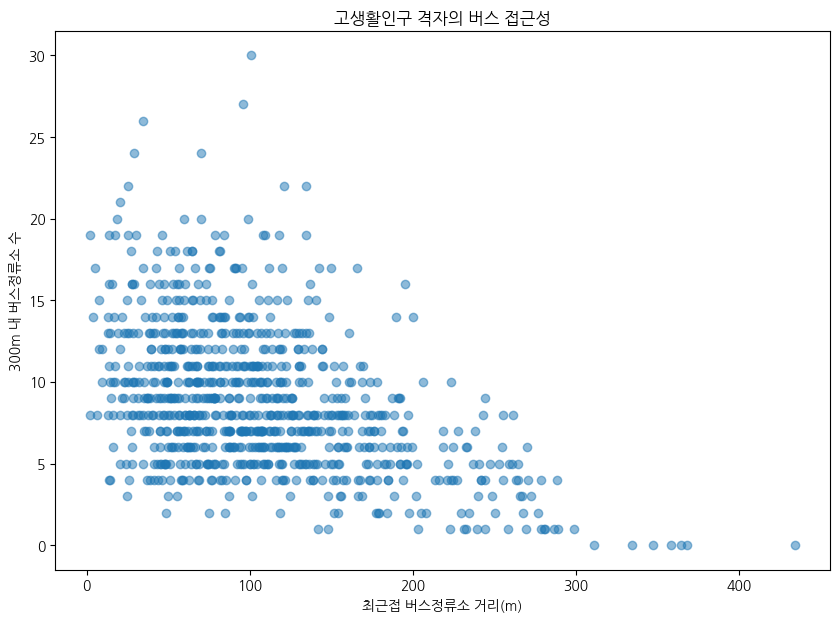

In [105]:
plt.figure(figsize=(10, 7))

plt.scatter(
    bus_analysis["최근접버스정류소거리_m"],
    bus_analysis["버스정류소수_300m"],
    alpha=0.5
)

plt.xlabel("최근접 버스정류소 거리(m)")
plt.ylabel("300m 내 버스정류소 수")
plt.title("고생활인구 격자의 버스 접근성")

plt.show()


## 28. 지하철 역사 데이터 전처리

In [ ]:
import pandas as pd
import geopandas as gpd

SUBWAY_PATH = ('/content/drive/MyDrive/교통공모전/서울시 역사마스터 정보.csv')

subway = pd.read_csv(
    SUBWAY_PATH,
    encoding="euc-kr",
    dtype={"역사_ID": "string"}
)

# 위경도 → 공간데이터
subway_gdf = gpd.GeoDataFrame(
    subway,
    geometry=gpd.points_from_xy(
        subway["경도"],
        subway["위도"]
    ),
    crs="EPSG:4326"
)

# 거리 계산용 좌표계로 변환
subway_5179 = subway_gdf.to_crs(epsg=5179)

print("역사 수:", len(subway_5179))
print("좌표계:", subway_5179.crs)
print("\n호선별 역사 수:")
print(subway_5179["호선"].value_counts())

display(subway_5179.head())

역사 수: 784
좌표계: EPSG:5179

호선별 역사 수:
호선
5호선           56
7호선           53
2호선           50
6호선           39
경부선           39
분당선           35
3호선           34
인천1호선         33
경원선           32
경의중앙선         27
인천2호선         27
4호선           26
9호선           25
중앙선           21
경인선           20
경춘선           19
8호선           19
수인선           18
서해선           15
의정부선          15
에버라인선         15
공항철도1호선       14
우이신설선         13
9호선(연장)       13
안산선           13
경강선           12
신림선           11
일산선           11
김포골드라인        10
수도권 광역급행철도    10
1호선           10
7호선(인천)        9
과천선            9
장항선            7
신분당선(연장)       7
신분당선           6
별내선            5
신분당선(연장2)      3
진접선            3
Name: count, dtype: int64


,역사_ID,역사명,호선,위도,경도,geometry
0,9010,동탄,수도권 광역급행철도,37.20034,127.09569,POINT (964120.607 1911358.633)
1,9009,구성,수도권 광역급행철도,37.29913,127.10389,POINT (964894.159 1922315.189)
2,9008,성남,수도권 광역급행철도,37.39467,127.12058,POINT (966415.922 1932908.37)
3,9007,수서,수도권 광역급행철도,37.48637,127.10161,POINT (964779.804 1943088.694)
4,9006,삼성,수도권 광역급행철도,37.50887,127.06324,POINT (961399.221 1945599.967)


## 29. 환승역 중복 확인

같은 역사명이 여러 노선에서 반복되었다.

중복 역사명: 110개

같은 이름의 역사 좌표 간 거리를 계산한 결과 일부는 실제 환승역이지만,
양평처럼 동일 이름이면서 수십 km 떨어진 별개의 역도 존재하였다.

따라서 단순히 역사명만 이용해 중복 제거하지 않았다.


In [ ]:
# 1. 동일한 위도/경도를 가진 역사
coord_dup = subway.duplicated(
    subset=["위도", "경도"],
    keep=False
)

print("동일 좌표에 있는 행 수:",
      coord_dup.sum())

print("동일 좌표 그룹 수:",
      subway.loc[
          coord_dup,
          ["위도", "경도"]
      ].drop_duplicates().shape[0])


# 2. 같은 역사명이 여러 번 등장하는 경우
name_count = (
    subway.groupby("역사명")
    .size()
    .sort_values(ascending=False)
)

print("\n2개 이상 존재하는 역사명 수:")
print((name_count >= 2).sum())

print("\n중복 역사명 상위:")
print(name_count[name_count >= 2].head(20))


# 3. 중복 역사명 샘플
dup_names = name_count[
    name_count >= 2
].index[:10]

display(
    subway[
        subway["역사명"].isin(dup_names)
    ][
        [
            "역사_ID",
            "역사명",
            "호선",
            "위도",
            "경도"
        ]
    ].sort_values("역사명")
)

동일 좌표에 있는 행 수: 6
동일 좌표 그룹 수: 3

2개 이상 존재하는 역사명 수:
110

중복 역사명 상위:
역사명
김포공항            5
서울역             5
공덕              4
연신내             3
왕십리(성동구청)       3
고속터미널           3
홍대입구            3
부천종합운동장         3
디지털미디어시티        3
동대문역사문화공원       3
수서              3
부평구청            3
종로3가            3
신설동             3
주안              2
지축              2
천호(풍납토성)        2
청구              2
청량리(서울시립대입구)    2
초지              2
dtype: int64


,역사_ID,역사명,호선,위도,경도
274,2736,고속터미널,7호선,37.503367,127.005068
131,4123,고속터미널,9호선,37.505980,127.004403
703,0329,고속터미널,3호선,37.504891,127.004916
322,2627,공덕,6호선,37.543555,126.951678
114,4202,공덕,공항철도1호선,37.542530,126.952024
375,2530,공덕,5호선,37.544431,126.951372
607,1262,공덕,경의중앙선,37.542596,126.952099
110,4207,김포공항,공항철도1호선,37.561842,126.801904
152,4102,김포공항,9호선,37.561916,126.802152
397,1980,김포공항,서해선,37.561700,126.804100


In [ ]:
import itertools
import pandas as pd

duplicate_names = (
    subway_5179["역사명"]
    .value_counts()
)

duplicate_names = duplicate_names[
    duplicate_names >= 2
].index

distance_rows = []

for name in duplicate_names:

    temp = subway_5179[
        subway_5179["역사명"] == name
    ].reset_index(drop=True)

    for i, j in itertools.combinations(
        range(len(temp)), 2
    ):

        dist = temp.geometry.iloc[i].distance(
            temp.geometry.iloc[j]
        )

        distance_rows.append({
            "역사명": name,
            "호선1": temp.loc[i, "호선"],
            "호선2": temp.loc[j, "호선"],
            "거리_m": dist
        })

same_name_distance = pd.DataFrame(distance_rows)

print("같은 역사명 좌표 간 거리 요약:")
print(
    same_name_distance["거리_m"]
    .describe()
)

print("\n500m 초과 조합 수:")
print(
    (same_name_distance["거리_m"] > 500).sum()
)

print("\n1km 초과 조합 수:")
print(
    (same_name_distance["거리_m"] > 1000).sum()
)

display(
    same_name_distance
    .sort_values("거리_m", ascending=False)
    .head(20)
)

같은 역사명 좌표 간 거리 요약:
count      155.000000
mean       499.821918
std       4307.690278
min          0.000000
25%         55.100061
50%        111.679919
75%        179.359421
max      53656.097421
Name: 거리_m, dtype: float64

500m 초과 조합 수:
4

1km 초과 조합 수:
2


,역사명,호선1,호선2,거리_m
137,양평,5호선,중앙선,53656.097421
138,운정,수도권 광역급행철도,경의중앙선,3588.437409
125,신촌,경의중앙선,2호선,715.249724
5,서울역,경의중앙선,4호선,508.677952
0,서울역,공항철도1호선,경의중앙선,455.828777
104,잠실(송파구청),8호선,2호선,401.953358
3,서울역,공항철도1호선,1호선,391.226110
9,서울역,4호선,1호선,381.034496
42,동대문역사문화공원,5호선,2호선,343.360426
83,청량리(서울시립대입구),경원선,1호선,339.906398


In [ ]:
# 각 250m 격자 중심점에서 최근접 지하철역 찾기
grid_subway = gpd.sjoin_nearest(
    grid_centers,
    subway_5179[
        [
            "역사_ID",
            "역사명",
            "호선",
            "geometry"
        ]
    ],
    how="left",
    distance_col="최근접지하철역거리_m"
)

print("생활인구 격자 수:", len(grid_centers))
print("거리 계산 후 행 수:", len(grid_subway))

print("\n최근접 지하철역 거리 요약:")
print(
    grid_subway["최근접지하철역거리_m"]
    .describe()
)

display(
    grid_subway[
        [
            "CELL_ID",
            "연평균생활인구",
            "역사명",
            "호선",
            "최근접지하철역거리_m"
        ]
    ].head(10)
)

생활인구 격자 수: 8617
거리 계산 후 행 수: 8657

최근접 지하철역 거리 요약:
count    8657.000000
mean      736.709456
std       545.268660
min         7.297703
25%       366.533393
50%       581.681441
75%       933.720791
max      3653.166419
Name: 최근접지하철역거리_m, dtype: float64


,CELL_ID,연평균생활인구,역사명,호선,최근접지하철역거리_m
0,다사54504050,233.245253,남태령,4호선,198.245267
1,다사54255700,52.450168,북한산보국문,우이신설선,2224.770351
2,다사54255725,8.288481,북한산보국문,우이신설선,2244.496835
3,다사54255575,6.262157,한성대입구(삼선교),4호선,2478.516923
4,다사54255600,186.858998,북한산보국문,우이신설선,2418.047021
5,다사54255625,6.523201,북한산보국문,우이신설선,2331.333165
6,다사54255650,6.258581,북한산보국문,우이신설선,2268.981546
7,다사54255775,2.000000,북한산보국문,우이신설선,2364.126034
8,다사54255850,2.000000,북한산보국문,우이신설선,2711.748641
9,다사54005750,49.169278,북한산보국문,우이신설선,2534.860565


## 30. 최근접 지하철역 거리
완전히 동일한 좌표의 역만 제거하였다.


In [ ]:
# 최근접 거리 계산용 지하철역
# 동일한 물리적 좌표는 1개만 사용
subway_locations = (
    subway_5179
    .drop_duplicates(
        subset=["위도", "경도"]
    )
    .copy()
)

print("원래 역사 행 수:", len(subway_5179))
print("중복 제거 후 역사 위치 수:", len(subway_locations))

원래 역사 행 수: 784
중복 제거 후 역사 위치 수: 781


In [ ]:
grid_subway = gpd.sjoin_nearest(
    grid_centers,
    subway_locations[
        [
            "역사_ID",
            "역사명",
            "호선",
            "geometry"
        ]
    ],
    how="left",
    distance_col="최근접지하철역거리_m"
)

print("생활인구 격자 수:", len(grid_centers))
print("거리 계산 후 행 수:", len(grid_subway))

print("\n최근접 지하철역 거리 요약:")
print(
    grid_subway["최근접지하철역거리_m"]
    .describe()
)

생활인구 격자 수: 8617
거리 계산 후 행 수: 8617

최근접 지하철역 거리 요약:
count    8617.000000
mean      738.341352
std       545.871304
min         7.297703
25%       367.236523
50%       583.020440
75%       935.430002
max      3653.166419
Name: 최근접지하철역거리_m, dtype: float64


In [ ]:
# 관측률 95% 이상 + 생활인구 상위 10%
high_pop_subway = grid_subway[
    (grid_subway["연간관측률"] >= 0.95) &
    (grid_subway["연평균생활인구"] >= pop_threshold)
].copy()

print("대상 격자 수:", len(high_pop_subway))

print("\n생활인구 상위 10%의 최근접 지하철역 거리:")
print(
    high_pop_subway["최근접지하철역거리_m"].describe()
)

대상 격자 수: 849

생활인구 상위 10%의 최근접 지하철역 거리:
count     849.000000
mean      460.229009
std       297.291283
min        26.422900
25%       250.363802
50%       403.711811
75%       596.574041
max      2219.100020
Name: 최근접지하철역거리_m, dtype: float64


In [ ]:
subway_far_top20 = (
    high_pop_subway
    .sort_values(
        "최근접지하철역거리_m",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접지하철역거리_m",
            "역사명",
            "호선"
        ]
    ]
    .head(20)
)

display(subway_far_top20)

,CELL_ID,연평균생활인구,최근접지하철역거리_m,역사명,호선
1341,다사64504075,4188.765987,2219.100020,수서,수도권 광역급행철도
2239,다사52005650,3803.604614,2072.733318,녹번,3호선
3443,다사48253900,4458.640846,2061.027403,석수,경부선
375,다사71255250,3614.027917,1671.214670,강일,5호선
5079,다사40754725,3406.792516,1653.650194,까치산,5호선
5690,다사62005350,4537.357210,1498.124190,회기,중앙선
671,다사68254175,4679.216474,1466.957161,복정,8호선
6789,다사59505875,4963.050159,1464.986465,미아(서울사이버대학),4호선
3820,다사47254125,4389.989150,1434.222162,독산,경부선
6659,다사59755850,4358.959526,1426.246493,월계,경원선


##31. 물리적 지하철역 생성
800m 내 역 개수를 계산할 때 환승역의 여러 노선을 별개의 역으로 계산하면 과대평가될 수 있다.

따라서 같은 역사명이면서 좌표가 600m 이내에 연결되어 있는 경우 동일 물리적 역사로 처리하였다.

결과:

호선별 역사: 784개

물리적 역사: 658개


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd

station_rows = []

for name, group in subway_5179.groupby("역사명"):

    group = group.reset_index(drop=True)
    n = len(group)

    # 같은 이름의 역이 1개뿐이면 그대로
    if n == 1:
        station_rows.append({
            "역사명": name,
            "호선": group.loc[0, "호선"],
            "geometry": group.loc[0, "geometry"]
        })
        continue

    # 연결관계 생성: 600m 이내면 같은 물리적 역으로 간주
    visited = [False] * n

    for start in range(n):

        if visited[start]:
            continue

        stack = [start]
        component = []
        visited[start] = True

        while stack:
            i = stack.pop()
            component.append(i)

            for j in range(n):
                if not visited[j]:
                    dist = group.geometry.iloc[i].distance(
                        group.geometry.iloc[j]
                    )

                    if dist <= 600:
                        visited[j] = True
                        stack.append(j)

        temp = group.iloc[component]

        # 같은 환승역의 대표점 = 좌표 평균
        mean_x = temp.geometry.x.mean()
        mean_y = temp.geometry.y.mean()

        station_rows.append({
            "역사명": name,
            "호선": ", ".join(sorted(temp["호선"].unique())),
            "geometry": gpd.points_from_xy(
                [mean_x], [mean_y]
            )[0]
        })

physical_subway = gpd.GeoDataFrame(
    station_rows,
    geometry="geometry",
    crs="EPSG:5179"
)

print("원래 호선별 역사 행 수:", len(subway_5179))
print("물리적 역사 수:", len(physical_subway))

display(physical_subway.head(10))

원래 호선별 역사 행 수: 784
물리적 역사 수: 658


,역사명,호선,geometry
0,4.19민주묘지,우이신설선,POINT (957100.209 1961223.89)
1,가능,경원선,POINT (959846.777 1972202.468)
2,가락시장,"3호선, 8호선",POINT (966238.43 1943770.12)
3,가산디지털단지,"7호선, 경부선",POINT (945415.473 1942592.875)
4,가양,9호선,POINT (942986.753 1951533.037)
5,가오리,우이신설선,POINT (957369.562 1960338.786)
6,가재울,인천2호선,POINT (927828.948 1943085.426)
7,가정(루원시티),인천2호선,POINT (927149.138 1947580.224)
8,가정중앙시장,인천2호선,POINT (927241.878 1946736.712)
9,가좌,경의중앙선,POINT (948381.848 1952285.476)


## 32. 800m 내 지하철역 수

In [ ]:
# 1. 격자 중심점 기준 800m 버퍼
grid_buffer_800 = grid_centers[
    ["CELL_ID", "geometry"]
].copy()

grid_buffer_800["geometry"] = (
    grid_buffer_800.geometry.buffer(800)
)


# 2. 800m 안에 있는 물리적 지하철역 매칭
subway_800_join = gpd.sjoin(
    physical_subway[
        ["역사명", "geometry"]
    ],
    grid_buffer_800,
    how="inner",
    predicate="within"
)


# 3. 격자별 지하철역 수
subway_count_800 = (
    subway_800_join
    .groupby("CELL_ID")
    .size()
    .rename("지하철역수_800m")
)


# 4. grid_subway에 결합
grid_subway["지하철역수_800m"] = (
    grid_subway["CELL_ID"]
    .map(subway_count_800)
    .fillna(0)
    .astype(int)
)


print("800m 내 지하철역 수 요약:")
print(
    grid_subway["지하철역수_800m"]
    .describe()
)

print("\n800m 내 지하철역이 없는 격자 수:")
print(
    (grid_subway["지하철역수_800m"] == 0).sum()
)

800m 내 지하철역 수 요약:
count    8617.000000
mean        1.138563
std         1.062604
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: 지하철역수_800m, dtype: float64

800m 내 지하철역이 없는 격자 수:
2819


In [ ]:
# 생활인구 상위 10% + 관측률 95% 이상
high_pop_subway = grid_subway[
    (grid_subway["연간관측률"] >= 0.95) &
    (grid_subway["연평균생활인구"] >= pop_threshold)
].copy()

print("대상 격자 수:", len(high_pop_subway))

print("\n생활인구 상위 10%의 800m 내 지하철역 수:")
print(
    high_pop_subway["지하철역수_800m"].describe()
)

print("\n800m 내 지하철역이 없는 격자 수:")
print(
    (high_pop_subway["지하철역수_800m"] == 0).sum()
)

대상 격자 수: 849

생활인구 상위 10%의 800m 내 지하철역 수:
count    849.000000
mean       1.654888
std        1.072756
min        0.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        6.000000
Name: 지하철역수_800m, dtype: float64

800m 내 지하철역이 없는 격자 수:
96


고생활인구 849개 중:
800m 내 역이 없는 격자: 96개


In [ ]:
display(
    high_pop_subway[
        high_pop_subway["지하철역수_800m"] == 0
    ][
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접지하철역거리_m",
            "지하철역수_800m",
            "역사명",
            "호선"
        ]
    ]
    .sort_values(
        "최근접지하철역거리_m",
        ascending=False
    )
    .head(20)
)

,CELL_ID,연평균생활인구,최근접지하철역거리_m,지하철역수_800m,역사명,호선
1341,다사64504075,4188.765987,2219.100020,0,수서,수도권 광역급행철도
2239,다사52005650,3803.604614,2072.733318,0,녹번,3호선
3443,다사48253900,4458.640846,2061.027403,0,석수,경부선
375,다사71255250,3614.027917,1671.214670,0,강일,5호선
5079,다사40754725,3406.792516,1653.650194,0,까치산,5호선
5690,다사62005350,4537.357210,1498.124190,0,회기,중앙선
671,다사68254175,4679.216474,1466.957161,0,복정,8호선
6789,다사59505875,4963.050159,1464.986465,0,미아(서울사이버대학),4호선
3820,다사47254125,4389.989150,1434.222162,0,독산,경부선
6659,다사59755850,4358.959526,1426.246493,0,월계,경원선


## 33. 지하철 접근 취약도

subway_analysis["지하철접근취약도"] = (
    (
        subway_analysis[
            "지하철거리취약도"
        ]
        +
        subway_analysis[
            "지하철역수취약도"
        ]
    )
    / 2
    * 100
)


In [ ]:
# 생활인구 상위 10% 데이터 복사
subway_analysis = high_pop_subway.copy()

# 1. 최근접 지하철역 거리 취약도
# 멀수록 높은 점수
subway_analysis["지하철거리취약도"] = (
    subway_analysis["최근접지하철역거리_m"]
    .rank(pct=True)
)

# 2. 800m 내 지하철역 수 취약도
# 역이 적을수록 높은 점수
subway_analysis["지하철역수취약도"] = (
    subway_analysis["지하철역수_800m"]
    .rank(pct=True, ascending=False)
)

# 3. 두 지표 동일 가중치로 결합
subway_analysis["지하철접근취약도"] = (
    (
        subway_analysis["지하철거리취약도"]
        + subway_analysis["지하철역수취약도"]
    ) / 2 * 100
)

# 취약도 상위 20개
subway_weak_top20 = (
    subway_analysis
    .sort_values(
        "지하철접근취약도",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접지하철역거리_m",
            "지하철역수_800m",
            "지하철접근취약도",
            "역사명",
            "호선"
        ]
    ]
    .head(20)
)

display(subway_weak_top20)

,CELL_ID,연평균생활인구,최근접지하철역거리_m,지하철역수_800m,지하철접근취약도,역사명,호선
1341,다사64504075,4188.765987,2219.100020,0,97.202591,수서,수도권 광역급행철도
2239,다사52005650,3803.604614,2072.733318,0,97.143698,녹번,3호선
3443,다사48253900,4458.640846,2061.027403,0,97.084806,석수,경부선
375,다사71255250,3614.027917,1671.214670,0,97.025913,강일,5호선
5079,다사40754725,3406.792516,1653.650194,0,96.967020,까치산,5호선
5690,다사62005350,4537.357210,1498.124190,0,96.908127,회기,중앙선
671,다사68254175,4679.216474,1466.957161,0,96.849234,복정,8호선
6789,다사59505875,4963.050159,1464.986465,0,96.790342,미아(서울사이버대학),4호선
3820,다사47254125,4389.989150,1434.222162,0,96.731449,독산,경부선
6659,다사59755850,4358.959526,1426.246493,0,96.672556,월계,경원선


## 34. 시각화 6 — 최근접 지하철역 거리 분포

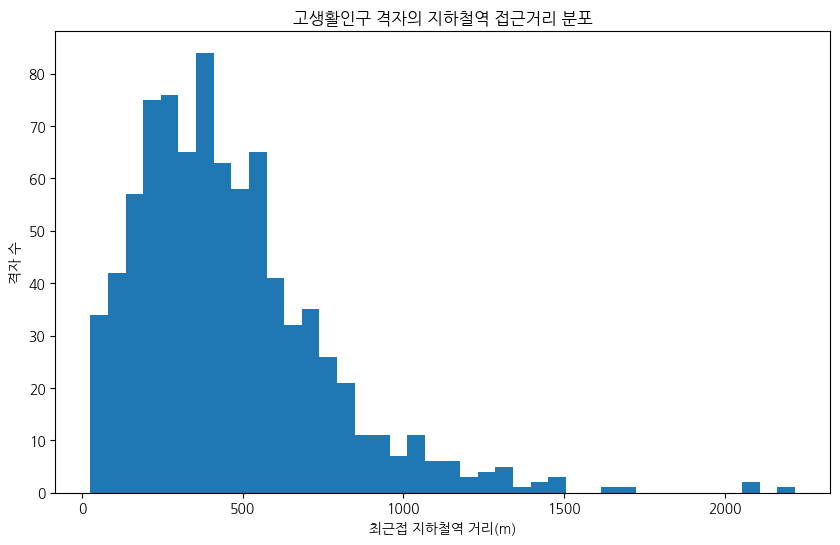

In [106]:
plt.figure(figsize=(10, 6))

plt.hist(
    high_pop_subway[
        "최근접지하철역거리_m"
    ],
    bins=40
)

plt.xlabel("최근접 지하철역 거리(m)")
plt.ylabel("격자 수")
plt.title("고생활인구 격자의 지하철역 접근거리 분포")

plt.show()


지하철의 경우 버스보다 거리 분포의 차이가 크게 나타나므로 취약지역을 구분하는 데 중요한 변수로 작용한다.
________________________________________


## 35. 버스·지하철 접근성 결합

In [ ]:
# 버스 분석 결과에서 필요한 변수
bus_part = bus_analysis[
    [
        "CELL_ID",
        "연평균생활인구",
        "최근접버스정류소거리_m",
        "버스정류소수_300m",
        "버스접근취약도",
        "geometry"
    ]
].copy()

# 지하철 분석 결과에서 필요한 변수
subway_part = subway_analysis[
    [
        "CELL_ID",
        "최근접지하철역거리_m",
        "지하철역수_800m",
        "지하철접근취약도"
    ]
].copy()

# CELL_ID 기준 결합
transit_analysis = bus_part.merge(
    subway_part,
    on="CELL_ID",
    how="inner"
)

# 종합 대중교통 접근 취약도
transit_analysis["대중교통접근취약도"] = (
    transit_analysis["버스접근취약도"] * 0.5
    +
    transit_analysis["지하철접근취약도"] * 0.5
)

print("결합 후 격자 수:", len(transit_analysis))

print("\n종합 취약도 요약:")
print(
    transit_analysis["대중교통접근취약도"].describe()
)

결합 후 격자 수: 849

종합 취약도 요약:
count    849.000000
mean      50.058893
std       17.416225
min        6.816843
25%       38.471731
50%       50.147232
75%       62.028857
max       96.319199
Name: 대중교통접근취약도, dtype: float64


In [ ]:
transit_top20 = (
    transit_analysis
    .sort_values(
        "대중교통접근취약도",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "최근접지하철역거리_m",
            "지하철역수_800m",
            "버스접근취약도",
            "지하철접근취약도",
            "대중교통접근취약도"
        ]
    ]
    .head(20)
)

display(transit_top20)

,CELL_ID,연평균생활인구,최근접버스정류소거리_m,버스정류소수_300m,최근접지하철역거리_m,지하철역수_800m,버스접근취약도,지하철접근취약도,대중교통접근취약도
389,다사47255750,4314.649231,272.806682,3,1328.345747,0,96.142521,96.495878,96.319199
768,다사57754125,5450.006081,184.271309,2,1311.599924,0,92.255595,96.319199,94.287397
6,다사54005000,5542.193172,278.654743,4,813.254068,0,93.963486,91.961131,92.962309
131,다사64754175,3504.398890,184.628500,4,1217.421449,0,88.957597,96.024735,92.491166
511,다사41504725,3544.819909,259.378862,5,1092.448770,0,89.016490,95.200236,92.108363
523,다사41004850,4005.037333,154.447233,2,937.164259,0,88.427562,93.845701,91.136631
352,다사48005825,3674.389817,142.136147,1,908.778845,0,87.426384,93.551237,90.488810
211,다사52254275,4649.779454,155.869190,3,800.068078,0,87.603062,91.607774,89.605418
714,다사58506175,3944.270187,270.118789,6,826.122714,0,84.952886,92.314488,88.633687
315,다사49005850,4242.851019,280.755647,1,746.022600,1,98.439340,78.121319,88.280330


## 36. 생활인구 수요 반영
유효 격자 전체에서 생활인구 백분위를 계산하였다.


In [ ]:
# --------------------------------------------------
# 1. 서울 전체 유효 격자에서 생활인구 백분위 계산
# --------------------------------------------------

valid_population = grid_bus[
    grid_bus["연간관측률"] >= 0.95
].copy()

valid_population["생활인구백분위"] = (
    valid_population["연평균생활인구"]
    .rank(pct=True)
    * 100
)

# CELL_ID → 생활인구 백분위
pop_pct_map = (
    valid_population
    .set_index("CELL_ID")["생활인구백분위"]
)

transit_analysis["생활인구백분위"] = (
    transit_analysis["CELL_ID"]
    .map(pop_pct_map)
)


# --------------------------------------------------
# 2. 최종 대중교통 취약 우선순위
# --------------------------------------------------

transit_analysis["최종취약우선순위"] = (
    transit_analysis["생활인구백분위"]
    *
    transit_analysis["대중교통접근취약도"]
    / 100
)


# --------------------------------------------------
# 3. TOP 20
# --------------------------------------------------

final_top20 = (
    transit_analysis
    .sort_values(
        "최종취약우선순위",
        ascending=False
    )
    [
        [
            "CELL_ID",
            "연평균생활인구",
            "생활인구백분위",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "최근접지하철역거리_m",
            "지하철역수_800m",
            "대중교통접근취약도",
            "최종취약우선순위"
        ]
    ]
    .head(20)
)

display(final_top20)

,CELL_ID,연평균생활인구,생활인구백분위,최근접버스정류소거리_m,버스정류소수_300m,최근접지하철역거리_m,지하철역수_800m,대중교통접근취약도,최종취약우선순위
768,다사57754125,5450.006081,98.455917,184.271309,2,1311.599924,0,94.287397,92.831521
389,다사47255750,4314.649231,95.638850,272.806682,3,1328.345747,0,96.319199,92.118574
6,다사54005000,5542.193172,98.609147,278.654743,4,813.254068,0,92.962309,91.669339
501,다사42004650,11656.926795,99.941066,266.895061,3,766.207527,1,87.279152,87.227714
211,다사52254275,4649.779454,96.888260,155.869190,3,800.068078,0,89.605418,86.817131
523,다사41004850,4005.037333,94.365865,154.447233,2,937.164259,0,91.136631,86.001871
131,다사64754175,3504.398890,91.277699,184.628500,4,1217.421449,0,92.491166,84.423808
511,다사41504725,3544.819909,91.525224,259.378862,5,1092.448770,0,92.108363,84.302385
315,다사49005850,4242.851019,95.379538,280.755647,1,746.022600,1,88.280330,84.201371
352,다사48005825,3674.389817,92.479962,142.136147,1,908.778845,0,90.488810,83.684018


즉 생활인구와 교통취약성이 동시에 높은 지역의 점수가 크게 나타난다.

## 37. 시각화 7 — 생활인구와 교통취약도 관계

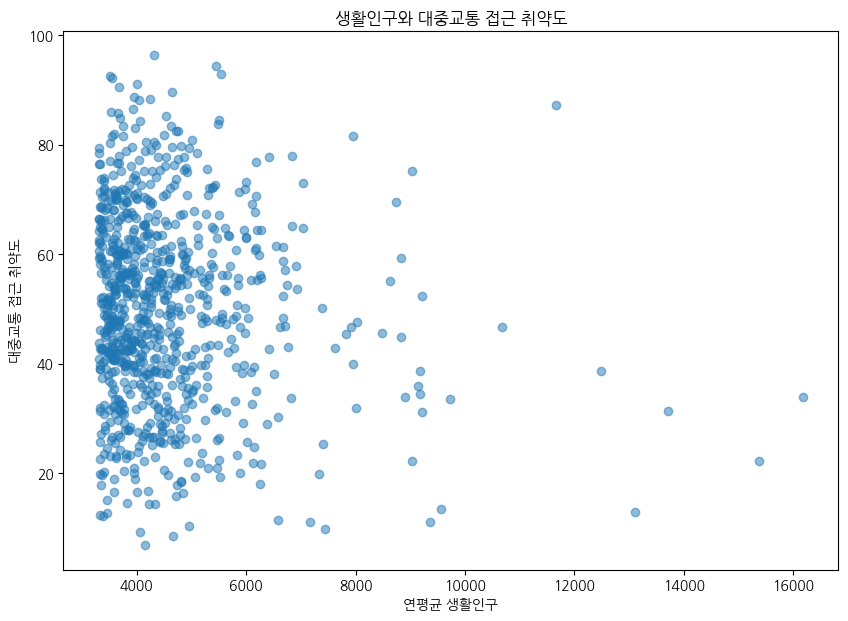

In [107]:
plt.figure(figsize=(10, 7))

plt.scatter(
    transit_analysis[
        "연평균생활인구"
    ],
    transit_analysis[
        "대중교통접근취약도"
    ],
    alpha=0.5
)

plt.xlabel("연평균 생활인구")
plt.ylabel("대중교통 접근 취약도")
plt.title("생활인구와 대중교통 접근 취약도")

plt.show()


오른쪽 위에 위치하는 격자가 본 분석에서 가장 중요한 후보이다.

생활인구가 많고 + 교통 접근성도 취약한 지역
이다.


## 38. 최종 TOP20 지도
최종점수 상위 20개를 지도에 강조하였다.


In [108]:
import geopandas as gpd
import folium

# --------------------------------------------------
# 1. GeoDataFrame으로 변환
# --------------------------------------------------

transit_gdf = gpd.GeoDataFrame(
    transit_analysis,
    geometry="geometry",
    crs="EPSG:5179"
)

# 최종 점수 기준 TOP 20
top20_gdf = (
    transit_gdf
    .sort_values(
        "최종취약우선순위",
        ascending=False
    )
    .head(20)
    .copy()
)

# 순위 추가
top20_gdf["순위"] = range(1, 21)

# 웹 지도용 좌표계
transit_wgs84 = transit_gdf.to_crs(epsg=4326)
top20_wgs84 = top20_gdf.to_crs(epsg=4326)


# --------------------------------------------------
# 2. 지도 생성
# --------------------------------------------------

m_final = folium.Map(
    location=[37.55, 126.98],
    zoom_start=11,
    tiles="CartoDB positron"
)


# --------------------------------------------------
# 3. 생활인구 상위 10% 전체 후보 - 배경
# --------------------------------------------------

folium.GeoJson(
    transit_wgs84,
    style_function=lambda feature: {
        "fillColor": "#bdbdbd",
        "color": "#ffffff",
        "weight": 0.2,
        "fillOpacity": 0.12
    }
).add_to(m_final)


# --------------------------------------------------
# 4. 최종 TOP 20 강조
# --------------------------------------------------

folium.GeoJson(
    top20_wgs84,
    style_function=lambda feature: {
        "fillColor": "#d7301f",
        "color": "#7f0000",
        "weight": 1.2,
        "fillOpacity": 0.75
    },
    tooltip=folium.GeoJsonTooltip(
        fields=[
            "순위",
            "CELL_ID",
            "연평균생활인구",
            "최근접버스정류소거리_m",
            "버스정류소수_300m",
            "최근접지하철역거리_m",
            "지하철역수_800m",
            "대중교통접근취약도",
            "최종취약우선순위"
        ],
        aliases=[
            "최종 순위:",
            "250m 격자:",
            "연평균 생활인구:",
            "최근접 버스정류소 거리(m):",
            "300m 내 버스정류소 수:",
            "최근접 지하철역 거리(m):",
            "800m 내 지하철역 수:",
            "접근 취약도:",
            "최종 우선순위 점수:"
        ],
        localize=True
    )
).add_to(m_final)

m_final

## 39. 행정동 이름 결합
전국 행정동 코드정보 중 2026년 8월 자료를 사용하였다.

초기에는 생활인구 행정동 코드 뒤에 공백이 존재하여 매칭되지 않았다.

250m 격자가 여러 행정동에 걸쳐 있을 수 있기 때문에 2026년 8월 한 달 동안
해당 격자의 생활인구가 가장 많이 배정된 행정동을 대표 행정동으로 사용하였다.

In [ ]:
import zipfile
import pandas as pd

ADMIN_ZIP = ('/content/drive/MyDrive/교통공모전/전국_행정동_코드정보.zip')

with zipfile.ZipFile(ADMIN_ZIP, "r") as z:
    admin = pd.read_csv(
        z.open("SEOUL_ADMI/ADMI_202608.csv"),
        encoding="utf-8-sig",
        dtype={"ADMI_CD": "string"}
    )

print("행정동 수:", len(admin))
print(admin.columns.tolist())

display(admin.head())

행정동 수: 3563
['SIDO_NM', 'SGG_NM', 'ADMI_NM', 'ADMI_CD', 'FULL_NM', 'BASE_YM']


,SIDO_NM,SGG_NM,ADMI_NM,ADMI_CD,FULL_NM,BASE_YM
0,서울특별시,종로구,청운효자동,11110515,서울특별시 종로구 청운효자동,202608
1,서울특별시,종로구,사직동,11110530,서울특별시 종로구 사직동,202608
2,서울특별시,종로구,삼청동,11110540,서울특별시 종로구 삼청동,202608
3,서울특별시,종로구,부암동,11110550,서울특별시 종로구 부암동,202608
4,서울특별시,종로구,평창동,11110560,서울특별시 종로구 평창동,202608


In [ ]:
print("생활인구 행정동코드 샘플:")
print(representative_dong["행정동코드"].head(10).tolist())

print("\n행정동 코드정보 ADMI_CD 샘플:")
print(admin["ADMI_CD"].head(10).tolist())

print("\n생활인구 코드 길이:")
print(
    representative_dong["행정동코드"]
    .astype(str)
    .str.len()
    .value_counts()
)

print("\n행정동 코드정보 코드 길이:")
print(
    admin["ADMI_CD"]
    .astype(str)
    .str.len()
    .value_counts()
)

생활인구 행정동코드 샘플:
['11470560     ', '11470590     ', '11500540     ', '11470610     ', '11470530     ', '11470540     ', '11470550     ', '11545620     ', '11380560     ', '11380551     ']

행정동 코드정보 ADMI_CD 샘플:
['11110515', '11110530', '11110540', '11110550', '11110560', '11110570', '11110580', '11110600', '11110615', '11110630']

생활인구 코드 길이:
행정동코드
13    20
Name: count, dtype: int64

행정동 코드정보 코드 길이:
ADMI_CD
8    3563
Name: count, dtype: int64


In [ ]:
# 1. 행정동 코드 공백 제거
representative_dong["행정동코드"] = (
    representative_dong["행정동코드"]
    .astype("string")
    .str.strip()
)

admin["ADMI_CD"] = (
    admin["ADMI_CD"]
    .astype("string")
    .str.strip()
)

print("생활인구 코드 길이:")
print(
    representative_dong["행정동코드"]
    .str.len()
    .value_counts()
)

print("\n매칭 가능한 코드 수:")
print(
    representative_dong["행정동코드"]
    .isin(admin["ADMI_CD"])
    .sum(),
    "/",
    len(representative_dong)
)

생활인구 코드 길이:
행정동코드
8    20
Name: count, dtype: Int64

매칭 가능한 코드 수:
20 / 20


In [ ]:
# 기존 지역명 컬럼을 제외하고 다시 결합
representative_dong_clean = representative_dong[
    [
        "250M격자",
        "행정동코드",
        "생활인구"
    ]
].copy()

representative_dong_clean = representative_dong_clean.merge(
    admin[
        [
            "ADMI_CD",
            "SGG_NM",
            "ADMI_NM",
            "FULL_NM"
        ]
    ],
    left_on="행정동코드",
    right_on="ADMI_CD",
    how="left"
)

# TOP 20에 지역명 결합
final_top20_area = final_top20.merge(
    representative_dong_clean[
        [
            "250M격자",
            "SGG_NM",
            "ADMI_NM",
            "FULL_NM"
        ]
    ],
    left_on="CELL_ID",
    right_on="250M격자",
    how="left"
)

display(
    final_top20_area[
        [
            "CELL_ID",
            "SGG_NM",
            "ADMI_NM",
            "연평균생활인구",
            "대중교통접근취약도",
            "최종취약우선순위"
        ]
    ]
)

,CELL_ID,SGG_NM,ADMI_NM,연평균생활인구,대중교통접근취약도,최종취약우선순위
0,다사57754125,서초구,양재1동,5450.006081,94.287397,92.831521
1,다사47255750,은평구,구산동,4314.649231,96.319199,92.118574
2,다사54005000,용산구,후암동,5542.193172,92.962309,91.669339
3,다사42004650,양천구,신월6동,11656.926795,87.279152,87.227714
4,다사52254275,관악구,행운동,4649.779454,89.605418,86.817131
5,다사41004850,양천구,신월1동,4005.037333,91.136631,86.001871
6,다사64754175,강남구,세곡동,3504.398890,92.491166,84.423808
7,다사41504725,양천구,신월4동,3544.819909,92.108363,84.302385
8,다사49005850,은평구,불광2동,4242.851019,88.280330,84.201371
9,다사48005825,은평구,갈현1동,3674.389817,90.488810,83.684018


In [ ]:
# TOP 20을 구별로 집계
top20_gu = (
    final_top20_area
    .groupby("SGG_NM")
    .agg(
        취약격자수=("CELL_ID", "count"),
        평균최종점수=("최종취약우선순위", "mean"),
        평균생활인구=("연평균생활인구", "mean")
    )
    .sort_values(
        ["취약격자수", "평균최종점수"],
        ascending=[False, False]
    )
    .reset_index()
)

display(top20_gu)

,SGG_NM,취약격자수,평균최종점수,평균생활인구
0,양천구,6,83.697080,5989.002837
1,은평구,3,86.667987,4077.296689
2,관악구,3,83.321792,4921.858089
3,동대문구,2,81.223296,4649.055462
4,서초구,1,92.831521,5450.006081
5,용산구,1,91.669339,5542.193172
6,강남구,1,84.423808,3504.398890
7,도봉구,1,83.316083,3944.270187
8,강서구,1,83.247826,5512.766895
9,금천구,1,81.178980,3933.127880


## 40. 최종 취약 후보 85개 선정
고생활인구 분석대상 849개 중 최종점수 상위 10%를 선택하였다.


In [ ]:
import numpy as np

# 849개의 상위 10% → 85개
n_top = int(np.ceil(len(transit_analysis) * 0.10))

top10_transit = (
    transit_analysis
    .sort_values(
        "최종취약우선순위",
        ascending=False
    )
    .head(n_top)
    .copy()
)

print("전체 분석 격자:", len(transit_analysis))
print("상위 10% 취약 후보:", len(top10_transit))

print("\n최종점수 범위:")
print(
    top10_transit["최종취약우선순위"]
    .agg(["min", "max"])
)

display(
    top10_transit[
        [
            "CELL_ID",
            "연평균생활인구",
            "대중교통접근취약도",
            "최종취약우선순위"
        ]
    ].head(10)
)

전체 분석 격자: 849
상위 10% 취약 후보: 85

최종점수 범위:
min    69.436795
max    92.831521
Name: 최종취약우선순위, dtype: float64


,CELL_ID,연평균생활인구,대중교통접근취약도,최종취약우선순위
768,다사57754125,5450.006081,94.287397,92.831521
389,다사47255750,4314.649231,96.319199,92.118574
6,다사54005000,5542.193172,92.962309,91.669339
501,다사42004650,11656.926795,87.279152,87.227714
211,다사52254275,4649.779454,89.605418,86.817131
523,다사41004850,4005.037333,91.136631,86.001871
131,다사64754175,3504.398890,92.491166,84.423808
511,다사41504725,3544.819909,92.108363,84.302385
315,다사49005850,4242.851019,88.280330,84.201371
352,다사48005825,3674.389817,90.488810,83.684018


In [ ]:
# 상위 10% 85개 격자
top85_ids = set(top10_transit["CELL_ID"])

dong_sum_list = []

with zipfile.ZipFile(AUG_ZIP, "r") as z:

    csv_files = [
        f for f in z.namelist()
        if f.endswith(".csv")
    ]

    for file in csv_files:

        df = pd.read_csv(
            z.open(file),
            encoding="cp949",
            usecols=[
                "행정동코드",
                "250M격자",
                "생활인구합계"
            ],
            dtype={
                "행정동코드": "string",
                "250M격자": "string"
            }
        )

        # 상위 85개 격자만
        df = df[
            df["250M격자"].isin(top85_ids)
        ].copy()

        # 코드 공백 제거
        df["행정동코드"] = (
            df["행정동코드"]
            .str.strip()
        )

        # '*' → 2명 대체
        df["생활인구"] = pd.to_numeric(
            df["생활인구합계"],
            errors="coerce"
        ).fillna(2.0)

        temp = (
            df.groupby(
                ["250M격자", "행정동코드"],
                as_index=False
            )["생활인구"]
            .sum()
        )

        dong_sum_list.append(temp)


# 8월 전체 합산
dong_85 = pd.concat(
    dong_sum_list,
    ignore_index=True
)

dong_85 = (
    dong_85
    .groupby(
        ["250M격자", "행정동코드"],
        as_index=False
    )["생활인구"]
    .sum()
)


# 격자별 대표 행정동
representative_85 = (
    dong_85
    .sort_values(
        ["250M격자", "생활인구"],
        ascending=[True, False]
    )
    .drop_duplicates("250M격자")
)


# 행정동명 결합
representative_85 = representative_85.merge(
    admin[
        [
            "ADMI_CD",
            "SGG_NM",
            "ADMI_NM"
        ]
    ],
    left_on="행정동코드",
    right_on="ADMI_CD",
    how="left"
)


# 85개 취약 후보에 지역명 결합
top85_area = top10_transit.merge(
    representative_85[
        [
            "250M격자",
            "SGG_NM",
            "ADMI_NM"
        ]
    ],
    left_on="CELL_ID",
    right_on="250M격자",
    how="left"
)

print("후보 격자 수:", len(top85_area))
print("지역명 결측:", top85_area["ADMI_NM"].isna().sum())

display(
    top85_area[
        [
            "CELL_ID",
            "SGG_NM",
            "ADMI_NM",
            "연평균생활인구",
            "최종취약우선순위"
        ]
    ].head(20)
)

후보 격자 수: 85
지역명 결측: 0


,CELL_ID,SGG_NM,ADMI_NM,연평균생활인구,최종취약우선순위
0,다사57754125,서초구,양재1동,5450.006081,92.831521
1,다사47255750,은평구,구산동,4314.649231,92.118574
2,다사54005000,용산구,후암동,5542.193172,91.669339
3,다사42004650,양천구,신월6동,11656.926795,87.227714
4,다사52254275,관악구,행운동,4649.779454,86.817131
5,다사41004850,양천구,신월1동,4005.037333,86.001871
6,다사64754175,강남구,세곡동,3504.398890,84.423808
7,다사41504725,양천구,신월4동,3544.819909,84.302385
8,다사49005850,은평구,불광2동,4242.851019,84.201371
9,다사48005825,은평구,갈현1동,3674.389817,83.684018


In [ ]:
gu_summary = (
    top85_area
    .groupby("SGG_NM")
    .agg(
        취약격자수=("CELL_ID", "count"),
        평균최종점수=("최종취약우선순위", "mean"),
        최고최종점수=("최종취약우선순위", "max"),
        평균생활인구=("연평균생활인구", "mean")
    )
    .sort_values(
        ["취약격자수", "평균최종점수"],
        ascending=[False, False]
    )
    .reset_index()
)

# 85개 중 차지하는 비율
gu_summary["취약격자비율_%"] = (
    gu_summary["취약격자수"] / len(top85_area) * 100
).round(1)

display(gu_summary)

,SGG_NM,취약격자수,평균최종점수,최고최종점수,평균생활인구,취약격자비율_%
0,양천구,12,79.181109,87.227714,5141.249631,14.1
1,강남구,9,74.498763,84.423808,4598.619118,10.6
2,은평구,8,78.901992,92.118574,4176.441064,9.4
3,동대문구,8,75.748740,82.214585,4555.237232,9.4
4,송파구,7,75.239963,78.672860,5727.762982,8.2
5,강동구,7,73.210859,79.058294,4575.218473,8.2
6,관악구,6,78.907838,86.817131,4357.575385,7.1
7,노원구,6,73.185322,77.606833,4698.791443,7.1
8,금천구,5,75.473243,81.178980,4116.165181,5.9
9,도봉구,4,75.630260,83.316083,4537.683050,4.7


41. 시각화 8 — 자치구별 취약 후보 수

자치구별 후보 격자 수를 시각화하면 특정 지역에 취약 후보가 집중되는 현상을 쉽게 확인할 수 있다.


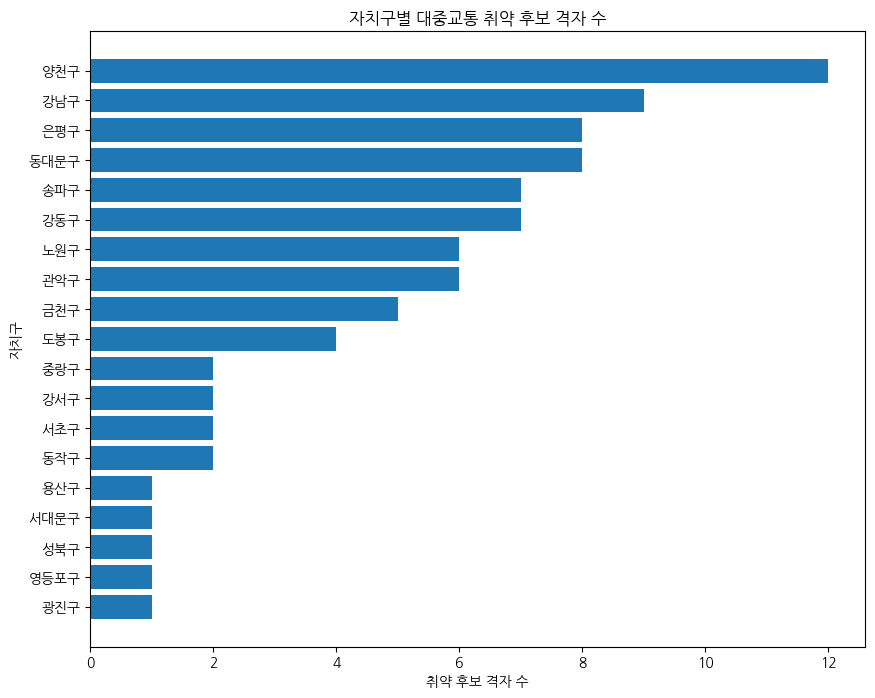

In [111]:
gu_summary_plot = (
    top85_area
    .groupby("SGG_NM")
    .size()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    gu_summary_plot.index,
    gu_summary_plot.values
)

plt.xlabel("취약 후보 격자 수")
plt.ylabel("자치구")
plt.title("자치구별 대중교통 취약 후보 격자 수")

plt.show()


In [ ]:
dong_summary = (
    top85_area
    .groupby(
        ["SGG_NM", "ADMI_NM"]
    )
    .agg(
        취약격자수=("CELL_ID", "count"),
        평균최종점수=("최종취약우선순위", "mean"),
        최고최종점수=("최종취약우선순위", "max"),
        평균생활인구=("연평균생활인구", "mean")
    )
    .sort_values(
        ["취약격자수", "평균최종점수"],
        ascending=[False, False]
    )
    .reset_index()
)

# 취약 격자가 2개 이상 존재하는 행정동만 우선 확인
dong_cluster = dong_summary[
    dong_summary["취약격자수"] >= 2
].copy()

display(dong_cluster)

,SGG_NM,ADMI_NM,취약격자수,평균최종점수,최고최종점수,평균생활인구
0,동대문구,답십리2동,3,75.433190,80.232006,4222.249167
1,동대문구,장안2동,2,79.649029,82.214585,4594.319912
2,강서구,화곡1동,2,78.334846,83.247826,5191.334743
3,금천구,독산3동,2,76.082378,78.784752,4007.393882
4,노원구,공릉2동,2,75.622901,76.502961,4041.796620
5,강동구,천호2동,2,74.841538,79.058294,5437.925095
6,노원구,중계1동,2,74.265541,77.606833,5100.058344
7,강남구,대치4동,2,73.660647,77.577151,5276.875358
8,강남구,개포4동,2,71.406339,71.595837,5354.027604


## 42. DBSCAN 공간 군집분석
행정동 경계를 기준으로 하면 실제로 가까운 격자가 서로 다른 동에 포함되어 하나의 권역으로 탐지되지 않을 수 있다.

따라서 85개 취약후보의 실제 위치를 이용하여 DBSCAN을 적용하였다.


In [112]:
from sklearn.cluster import DBSCAN
import geopandas as gpd
import pandas as pd

# 공간데이터로 변환
top85_geo = gpd.GeoDataFrame(
    top85_area.copy(),
    geometry="geometry",
    crs="EPSG:5179"
)

# 중심점 좌표
coords = pd.DataFrame({
    "x": top85_geo.geometry.x,
    "y": top85_geo.geometry.y
}).values

# 500m 이내 격자끼리 군집
dbscan = DBSCAN(
    eps=500,          # 500m
    min_samples=2
)

top85_geo["군집"] = dbscan.fit_predict(coords)

# -1 = 주변에 다른 후보가 없는 단독 격자
print("전체 후보:", len(top85_geo))
print(
    "공간 군집 수:",
    top85_geo.loc[top85_geo["군집"] != -1, "군집"].nunique()
)
print(
    "단독 격자 수:",
    (top85_geo["군집"] == -1).sum()
)

전체 후보: 85
공간 군집 수: 10
단독 격자 수: 61


In [113]:
cluster_summary = (
    top85_geo[
        top85_geo["군집"] != -1
    ]
    .groupby("군집")
    .agg(
        격자수=("CELL_ID", "count"),
        평균최종점수=("최종취약우선순위", "mean"),
        최고최종점수=("최종취약우선순위", "max"),
        평균생활인구=("연평균생활인구", "mean"),
        자치구=("SGG_NM", lambda x: ", ".join(sorted(set(x)))),
        행정동=("ADMI_NM", lambda x: ", ".join(sorted(set(x))))
    )
    .sort_values(
        ["격자수", "평균최종점수"],
        ascending=[False, False]
    )
    .reset_index()
)

display(cluster_summary)

,군집,격자수,평균최종점수,최고최종점수,평균생활인구,자치구,행정동
0,5,5,74.860732,80.232006,4249.668872,동대문구,"답십리2동, 전농1동, 전농2동"
1,1,3,79.189190,86.817131,4621.658245,"관악구, 동작구","사당5동, 청림동, 행운동"
2,0,2,82.984357,87.227714,7677.758051,양천구,"신월6동, 신정3동"
3,2,2,80.627750,83.684018,4318.712824,은평구,"갈현1동, 갈현2동"
4,3,2,77.363026,83.316083,4685.808030,도봉구,"쌍문2동, 쌍문4동"
5,7,2,76.082378,78.784752,4007.393882,금천구,독산3동
6,9,2,75.622901,76.502961,4041.796620,노원구,공릉2동
7,4,2,75.307887,81.178980,4088.024495,금천구,"독산2동, 시흥4동"
8,6,2,75.180519,79.144197,4817.134736,강남구,"개포1동, 개포4동"
9,8,2,74.265541,77.606833,5100.058344,노원구,중계1동


## 43. 시각화 9 — 공간 군집 인터랙티브 지도

In [114]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# WGS84 변환
cluster_map_gdf = top85_geo.to_crs(epsg=4326).copy()

# 지도 생성
m_cluster = folium.Map(
    location=[37.55, 126.98],
    zoom_start=11,
    tiles="CartoDB positron"
)

# 군집별 색상
cluster_ids = sorted(
    cluster_map_gdf.loc[
        cluster_map_gdf["군집"] != -1,
        "군집"
    ].unique()
)

colors = list(mcolors.TABLEAU_COLORS.values())

cluster_color = {
    cid: colors[i % len(colors)]
    for i, cid in enumerate(cluster_ids)
}

# 후보 격자 표시
for _, row in cluster_map_gdf.iterrows():

    cluster_id = row["군집"]

    # 단독 후보는 회색
    if cluster_id == -1:
        color = "#bdbdbd"
        radius = 4
        opacity = 0.45
        cluster_name = "단독 후보"

    else:
        color = cluster_color[cluster_id]
        radius = 7
        opacity = 0.9
        cluster_name = f"군집 {cluster_id}"

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=opacity,
        weight=1,
        tooltip=(
            f"{cluster_name}<br>"
            f"{row['SGG_NM']} {row['ADMI_NM']}<br>"
            f"격자: {row['CELL_ID']}<br>"
            f"생활인구: {row['연평균생활인구']:.0f}<br>"
            f"최종점수: {row['최종취약우선순위']:.1f}"
        )
    ).add_to(m_cluster)

m_cluster

## 44. 군집 거리 민감도 분석
DBSCAN의 거리기준이 결과에 영향을 줄 수 있으므로 400m, 500m, 600m를 비교하였다.


In [97]:
from sklearn.cluster import DBSCAN
import pandas as pd

results = []

for eps in [400, 500, 600]:

    labels = DBSCAN(
        eps=eps,
        min_samples=2
    ).fit_predict(coords)

    temp = top85_geo.copy()
    temp["군집_test"] = labels

    # 군집에 포함된 격자만
    clustered = temp[
        temp["군집_test"] != -1
    ]

    cluster_sizes = (
        clustered
        .groupby("군집_test")
        .size()
    )

    results.append({
        "거리기준_m": eps,
        "군집수": cluster_sizes.size,
        "군집포함격자수": len(clustered),
        "단독격자수": (labels == -1).sum(),
        "최대군집크기": (
            cluster_sizes.max()
            if len(cluster_sizes) > 0
            else 0
        )
    })

sensitivity = pd.DataFrame(results)

display(sensitivity)

,거리기준_m,군집수,군집포함격자수,단독격자수,최대군집크기
0,400,5,10,75,2
1,500,10,24,61,5
2,600,16,38,47,5


거리 기준에 따라 군집 결과가 달라졌기 때문에 가장 엄격한 400m에서도 유지되는 군집을 핵심 취약권역으로 정의하였다.


## 45. 시각화 10 — 군집 거리기준 민감도

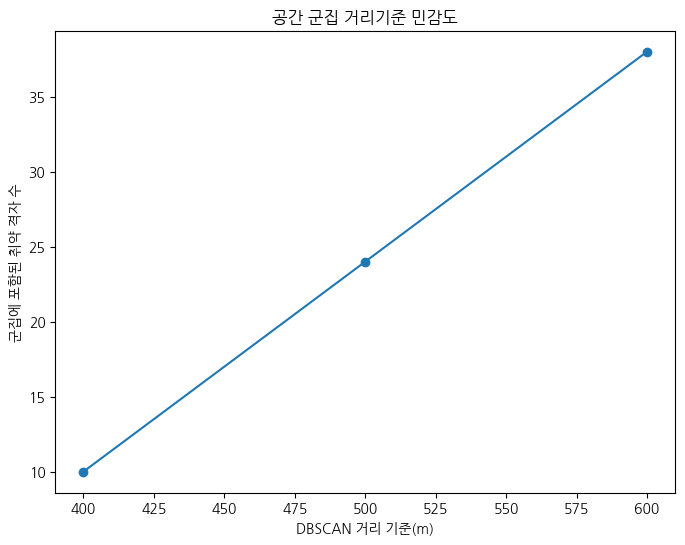

In [119]:
plt.figure(figsize=(8, 6))

plt.plot(
    sensitivity["거리기준_m"],
    sensitivity["군집포함격자수"],
    marker="o"
)

plt.xlabel("DBSCAN 거리 기준(m)")
plt.ylabel("군집에 포함된 취약 격자 수")
plt.title("공간 군집 거리기준 민감도")

plt.show()


400m에서 600m로 확대될수록 군집 격자 수가 빠르게 증가한다.

따라서 넓은 거리기준을 사용할 경우 서로 분리된 후보들을 과도하게 하나의 권역으로 해석할 가능성이 존재한다.


In [117]:
# 400m 기준 군집 다시 생성
labels_400 = DBSCAN(
    eps=400,
    min_samples=2
).fit_predict(coords)

core400 = top85_geo.copy()
core400["군집_400m"] = labels_400

# 단독 격자 제외
core400_clustered = core400[
    core400["군집_400m"] != -1
].copy()

# 핵심 군집 요약
core400_summary = (
    core400_clustered
    .groupby("군집_400m")
    .agg(
        격자수=("CELL_ID", "count"),
        평균최종점수=("최종취약우선순위", "mean"),
        최고최종점수=("최종취약우선순위", "max"),
        평균생활인구=("연평균생활인구", "mean"),
        자치구=("SGG_NM", lambda x: ", ".join(sorted(set(x)))),
        행정동=("ADMI_NM", lambda x: ", ".join(sorted(set(x)))),
        격자ID=("CELL_ID", lambda x: ", ".join(x))
    )
    .sort_values(
        "평균최종점수",
        ascending=False
    )
    .reset_index()
)

display(core400_summary)

,군집_400m,격자수,평균최종점수,최고최종점수,평균생활인구,자치구,행정동,격자ID
0,0,2,82.984357,87.227714,7677.758051,양천구,"신월6동, 신정3동","다사42004650, 다사42254650"
1,1,2,76.082378,78.784752,4007.393882,금천구,독산3동,"다사47004225, 다사47254200"
2,3,2,75.622901,76.502961,4041.796620,노원구,공릉2동,"다사63005825, 다사63005850"
3,2,2,74.265541,77.606833,5100.058344,노원구,중계1동,"다사62256125, 다사62506125"
4,4,2,73.033782,75.372391,3952.996893,동대문구,답십리2동,"다사61255250, 다사61005250"


In [116]:
core400_detail = (
    core400_clustered
    .groupby("군집_400m")
    .agg(
        격자수=("CELL_ID", "count"),
        자치구=("SGG_NM", lambda x: ", ".join(sorted(set(x)))),
        행정동=("ADMI_NM", lambda x: ", ".join(sorted(set(x)))),

        평균생활인구=("연평균생활인구", "mean"),

        평균최근접버스거리_m=(
            "최근접버스정류소거리_m", "mean"
        ),
        평균300m버스정류소수=(
            "버스정류소수_300m", "mean"
        ),

        평균최근접지하철거리_m=(
            "최근접지하철역거리_m", "mean"
        ),
        평균800m지하철역수=(
            "지하철역수_800m", "mean"
        ),

        평균버스취약도=(
            "버스접근취약도", "mean"
        ),
        평균지하철취약도=(
            "지하철접근취약도", "mean"
        ),

        평균최종점수=(
            "최종취약우선순위", "mean"
        )
    )
    .sort_values(
        "평균최종점수",
        ascending=False
    )
    .reset_index()
)

display(core400_detail)

,군집_400m,격자수,자치구,행정동,평균생활인구,평균최근접버스거리_m,평균300m버스정류소수,평균최근접지하철거리_m,평균800m지하철역수,평균버스취약도,평균지하철취약도,평균최종점수
0,0,2,양천구,"신월6동, 신정3동",7677.758051,350.727923,1.5,658.173309,1.0,97.835689,74.381625,82.984357
1,1,2,금천구,독산3동,4007.393882,154.970108,5.5,833.545808,0.5,76.914016,85.188457,76.082378
2,3,2,노원구,공릉2동,4041.796620,218.401003,4.5,616.422616,1.0,87.985866,72.084806,75.622901
3,2,2,노원구,중계1동,5100.058344,97.006505,7.0,1088.780801,0.0,56.507656,95.318021,74.265541
4,4,2,동대문구,답십리2동,3952.996893,119.958545,7.5,964.472527,0.0,61.425206,94.110718,73.033782


## 46. 핵심 취약권역 5개
400m 기준에서도 유지된 공간군집은 총 5개였다.


## 47. 핵심 취약권역 선정 기준

위 5개 지역은 단순히 최종점수가 높은 격자라는 이유만으로 선정된 것이 아니다.

핵심 취약권역은 다음 조건을 모두 통과한 지역이다.

첫 번째: 생활인구가 높은 지역
서울의 유효 생활인구 격자 중 상위 10%만 분석대상으로 사용하였다.
즉 애초에 생활인구 수요가 낮은 산지나 외곽지역은 핵심 분석대상에서 제외하였다.

두 번째: 버스 또는 지하철 접근성이 상대적으로 취약
최근접 거리뿐 아니라 주변 교통시설 수까지 동시에 사용하였다.
따라서 단순히 역이나 정류소 하나가 조금 멀다는 이유만으로 취약지역으로 선정되지 않는다.

세 번째: 생활인구와 접근 취약성을 동시에 반영
생활인구 백분위와 대중교통 접근 취약도를 곱하여 최종점수를 계산하였다.
따라서 수요가 높고 교통공급이 부족한 지역이 우선적으로 올라온다.

네 번째: 최종 후보 상위 10%
849개의 고생활인구 격자 중 최종점수 상위 10%인 85개만 공간 군집분석에 사용하였다.

다섯 번째: 공간적으로 반복되는 지역
개별 격자 하나가 우연히 높은 점수를 받은 경우를 핵심권역으로 선정하지 않았다.
인접한 복수의 고취약 격자가 존재해야 한다.

여섯 번째: 가장 엄격한 400m 기준에서도 군집 유지
400m, 500m, 600m를 비교한 결과 거리기준에 따라 군집 수가 달라졌다.
이에 가장 엄격한 400m 기준에서도 최소 2개 이상의 후보가 붙어 있는 지역만 핵심 취약권역으로 선정하였다.
즉 최종 5개 권역은 높은 수요 + 낮은 접근성 + 높은 최종점수 + 공간적 반복성 + 거리기준 강건성을 동시에 만족한다.


## 48. 핵심권역별 선정 이유
### 48.1 1순위 — 양천구 신월6동·신정3동
평균 생활인구:
약 7,678명

평균 최종점수:
82.98점

최근접 버스정류소 평균거리:
350.7m

300m 내 버스정류소:
평균 1.5개

버스 접근 취약도:
97.84점

지하철 접근 취약도:
74.38점

이 지역은 5개 핵심권역 중 평균 생활인구와 평균 최종점수가 모두 가장 높다.

특히 버스 접근 취약도가 97.84점으로 매우 높다.

생활인구 수요가 매우 높은데도 평균적으로 가장 가까운 버스정류소가 약 351m 떨어져 있고, 300m 이내 버스정류소도 평균 1.5개에 불과하다.

따라서 해당 권역은 본 분석에서 가장 대표적인 고수요·버스 접근 취약지역으로 판단하였다.


48.2 금천구 독산3동

평균 생활인구:
약 4,007명

최근접 버스정류소:
약 155m

300m 내 버스정류소:
5.5개

최근접 지하철역:
약 834m

지하철 접근 취약도:
85.19점

버스정류소 접근성은 상대적으로 양호하지만 지하철역과의 거리가 길고 800m 내 역 수가 낮다.

따라서 독산3동은 지하철 접근 취약형으로 분류할 수 있다.


##48.3 노원구 공릉2동

평균 생활인구:
약 4,042명

최근접 버스정류소:
약 218m

300m 내 버스정류소:
4.5개

버스 접근 취약도:
87.99점

지하철 접근 취약도:
72.08점

다른 핵심지역에 비해 지하철보다 버스 취약도가 높게 나타났다.

따라서 공릉2동은 버스 접근 취약형의 성격이 상대적으로 강하다


## 48.4 노원구 중계1동

평균 생활인구:
약 5,100명

최근접 버스정류소:
약 97m

300m 내 버스정류소:
7개

최근접 지하철역:
약 1,089m

800m 내 지하철역:
0개

지하철 접근 취약도:
95.32점

버스 접근성은 상당히 좋은 편이다.

그러나 800m 안에 지하철역이 없고 최근접 역도 평균 1km 이상 떨어져 있다.

따라서 중계1동은 매우 명확한 지하철 접근 취약형 지역이다


## 48.5 동대문구 답십리2동

평균 생활인구:
약 3,953명

최근접 버스정류소:
약 120m

300m 내 버스정류소:
7.5개

최근접 지하철역:
약 964m

800m 내 지하철역:
0개

지하철 접근 취약도:
94.11점

중계1동과 마찬가지로 버스 접근성은 상대적으로 양호하다.

반면 800m 내 지하철역이 존재하지 않고 최근접 역도 평균 약 1km 떨어져 있다.

따라서 답십리2동 역시 지하철 접근 취약형으로 해석하였다.


## 49. 시각화 11 — 핵심 취약권역 평균 최종점수 비교

In [ ]:
core_plot = (
    core400_detail
    .copy()
)

core_plot["지역"] = (
    core_plot["자치구"]
    + " "
    + core_plot["행정동"]
)

core_plot = (
    core_plot
    .sort_values(
        "평균최종점수",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    core_plot["지역"],
    core_plot["평균최종점수"]
)

plt.xlabel("평균 최종 취약 우선순위")
plt.ylabel("핵심 취약권역")
plt.title("핵심 취약권역별 최종점수 비교")

plt.show()


## 50. 시각화 12 — 버스 취약도와 지하철 취약도 유형 비교
각 핵심지역이 버스형인지 지하철형인지 보여주기 위한 시각화이다.


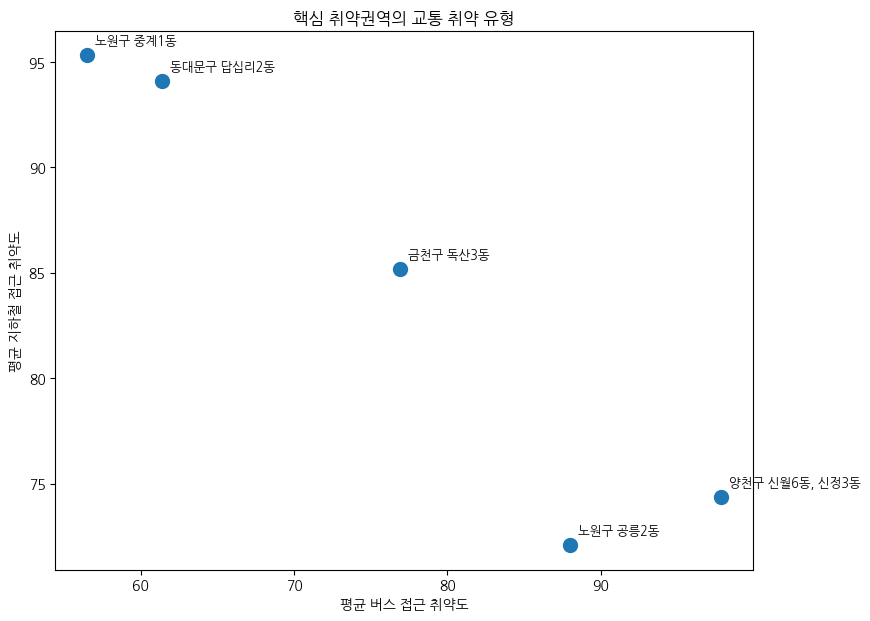

In [121]:
plt.figure(figsize=(9, 7))

plt.scatter(
    core400_detail[
        "평균버스취약도"
    ],
    core400_detail[
        "평균지하철취약도"
    ],
    s=100
)

for _, row in core400_detail.iterrows():

    label = (
        str(row["자치구"])
        + " "
        + str(row["행정동"])
    )

    plt.text(
        row["평균버스취약도"] + 0.5,
        row["평균지하철취약도"] + 0.5,
        label,
        fontsize=9
    )

plt.xlabel("평균 버스 접근 취약도")
plt.ylabel("평균 지하철 접근 취약도")
plt.title("핵심 취약권역의 교통 취약 유형")

plt.show()


## 51. 버스·지하철 가중치 민감도 분석
기준모형은 버스 50%, 지하철 50%이다.

그러나 가중치 선택에 따라 결과가 달라질 가능성을 검토하였다.


In [118]:
# 가중치별 종합 접근 취약도
transit_analysis["접근취약도_버스40"] = (
    transit_analysis["버스접근취약도"] * 0.4 +
    transit_analysis["지하철접근취약도"] * 0.6
)

transit_analysis["접근취약도_버스50"] = (
    transit_analysis["버스접근취약도"] * 0.5 +
    transit_analysis["지하철접근취약도"] * 0.5
)

transit_analysis["접근취약도_버스60"] = (
    transit_analysis["버스접근취약도"] * 0.6 +
    transit_analysis["지하철접근취약도"] * 0.4
)

# 생활인구까지 반영한 최종점수
for w in [40, 50, 60]:
    transit_analysis[f"최종점수_버스{w}"] = (
        transit_analysis["생활인구백분위"] *
        transit_analysis[f"접근취약도_버스{w}"] / 100
    )

# 순위 생성
for w in [40, 50, 60]:
    transit_analysis[f"순위_버스{w}"] = (
        transit_analysis[f"최종점수_버스{w}"]
        .rank(ascending=False, method="min")
    )

In [102]:
print("순위 상관관계:")
display(
    transit_analysis[
        ["순위_버스40", "순위_버스50", "순위_버스60"]
    ].corr(method="spearman")
)

# 각 시나리오 TOP 20
top40 = set(
    transit_analysis.nsmallest(20, "순위_버스40")["CELL_ID"]
)

top50 = set(
    transit_analysis.nsmallest(20, "순위_버스50")["CELL_ID"]
)

top60 = set(
    transit_analysis.nsmallest(20, "순위_버스60")["CELL_ID"]
)

print("40:60 vs 50:50 TOP20 공통:", len(top40 & top50))
print("50:50 vs 60:40 TOP20 공통:", len(top50 & top60))
print("40:60 vs 60:40 TOP20 공통:", len(top40 & top60))

순위 상관관계:


,순위_버스40,순위_버스50,순위_버스60
순위_버스40,1.000000,0.978857,0.916700
순위_버스50,0.978857,1.000000,0.978117
순위_버스60,0.916700,0.978117,1.000000


40:60 vs 50:50 TOP20 공통: 17
50:50 vs 60:40 TOP20 공통: 17
40:60 vs 60:40 TOP20 공통: 14


따라서 가중치를 다소 변경하더라도 전체적인 취약지역 순위는 크게 달라지지 않았다.

이는 분석 결과가 특정 가중치에 지나치게 의존하지 않는다는 것을 의미한다.


## 52. 시각화 13 — 가중치별 순위 안정성
세 시나리오의 순위를 직접 비교할 수도 있다.


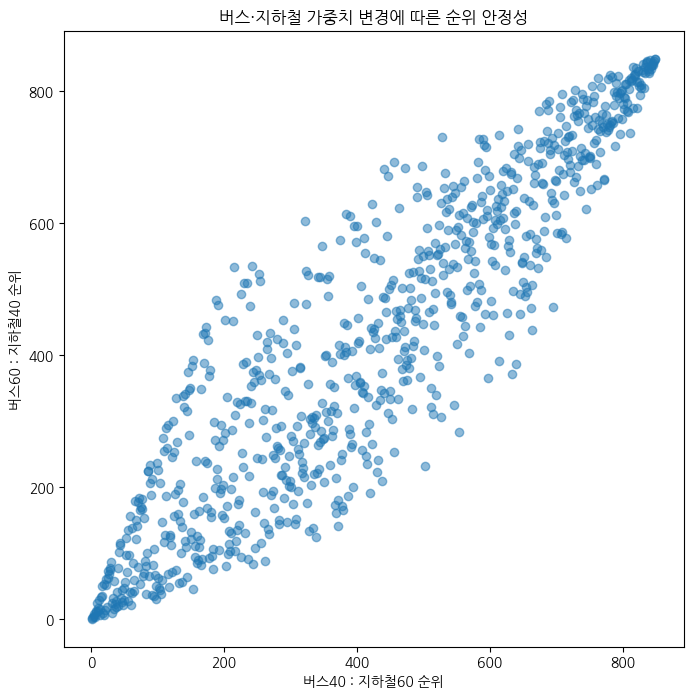

In [104]:
plt.figure(figsize=(8, 8))
plt.scatter( transit_analysis["순위_버스40"], transit_analysis["순위_버스60"], alpha=0.5 )
plt.xlabel("버스40 : 지하철60 순위")
plt.ylabel("버스60 : 지하철40 순위")
plt.title("버스·지하철 가중치 변경에 따른 순위 안정성")
plt.show()

In [103]:
OUTPUT_DIR = "/content/drive/MyDrive/seoul_population_250m"

# 1. 최종 상위 10% 후보 85개
top85_geo.to_file(
    f"{OUTPUT_DIR}/transit_vulnerable_top85.gpkg",
    layer="top85",
    driver="GPKG"
)

# CSV도 저장
top85_geo.drop(columns="geometry").to_csv(
    f"{OUTPUT_DIR}/transit_vulnerable_top85.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2. 400m 기준 핵심 군집 5개 요약
core400_detail.to_csv(
    f"{OUTPUT_DIR}/core_vulnerable_clusters_400m.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3. 가중치 민감도 결과
sensitivity_weights = transit_analysis[
    [
        "CELL_ID",
        "최종점수_버스40",
        "최종점수_버스50",
        "최종점수_버스60",
        "순위_버스40",
        "순위_버스50",
        "순위_버스60"
    ]
]

sensitivity_weights.to_csv(
    f"{OUTPUT_DIR}/weight_sensitivity.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


## 53. 최종 결과 해석
본 분석 결과 서울의 고생활인구 지역은 전체적으로 버스 및 지하철 접근성이 비교적 좋은 편이었다.

그러나 일부 지역에서는 생활인구 수요가 높은데도 대중교통 공급이 상대적으로 부족한 패턴이 확인되었다.

특히 단일 격자 수준의 점수만 이용하지 않고:

생활인구 수요 → 버스 접근성 → 지하철 접근성 → 최종점수 → 공간 군집 → 거리 민감도 → 가중치 민감도

순서로 검증함으로써 결과의 우연성을 줄였다.

최종적으로 가장 엄격한 400m 군집 기준에서도 다음 다섯 권역이 유지되었다.

양천구 신월6동·신정3동

금천구 독산3동

노원구 공릉2동

노원구 중계1동

동대문구 답십리2동

이 중 양천구 신월6동·신정3동은 생활인구가 가장 높으면서 버스 접근 취약도도 매우 높았기 때문에 본 분석에서 가장 우선적인 검토지역으로 도출되었다.

반면 중계1동과 답십리2동은 버스 공급은 비교적 양호하지만 지하철 접근성이 매우 낮은 지역으로 확인되었다.

즉 대중교통 취약지역은 모두 같은 유형이 아니며, 지역별로 다른 접근이 필요하다.


## 54. 분석의 한계

첫째, 버스정류소와 지하철역까지의 거리는 직선거리이다.

실제 보행자는 도로망, 횡단보도, 하천, 철도, 고도차 등을 따라 이동하므로 실제 도보거리는 더 길 수 있다.

둘째, 버스정류소 개수만 사용하였으며 노선 수와 배차간격은 반영하지 않았다.

따라서 정류소가 많더라도 실제 버스 서비스 수준이 낮은 지역이 존재할 수 있다.

셋째, 지하철역도 실제 운행 빈도나 급행운행, 환승 편의성까지는 반영하지 않았다.

넷째, 버스 300m와 지하철 800m는 절대적 기준이 아니라 접근성의 상대비교를 위한 분석 반경이다.

다섯째, 생활인구의 비식별 값 *은 2명으로 대체하였다.

여섯째, 생활인구 자료의 일부 누락 문제를 보완하기 위해 관측률 95% 이상만 사용하였다.

일곱째, 최종점수는 교통시설 신설의 직접적인 정책 우선순위를 의미하지 않는다.

본 결과는 추가 현장조사 및 교통수요 검토가 필요한 우선 검토지역을 선별하는 탐색적 분석결과로 보는 것이 적절하다


# 55. 최종 결론
본 분석에서는 서울의 250m 생활인구 데이터를 1년간 수집하고, 버스정류소 및 지하철역 공간정보와 결합하여 고생활인구 대비 대중교통 접근성이 상대적으로 부족한 지역을 탐색하였다.

365일 생활인구를 시간 단위로 전처리한 결과 8,619개 격자를 확보하였으며, 공간정보가 정상적으로 매칭된 8,617개 격자를 분석하였다.

이 중 데이터 관측률이 95% 이상이고 생활인구가 상위 10%에 해당하는 849개 격자를 주요 분석대상으로 설정하였다.

버스 접근성은 최근접 버스정류소 거리와 300m 내 정류소 수, 지하철 접근성은 최근접 지하철역 거리와 800m 내 물리적 지하철역 수를 이용하였다.

각 변수는 백분위 방식으로 표준화하여 버스·지하철 접근 취약도를 산정하였고, 두 취약도를 50:50으로 결합하였다.

이후 생활인구 백분위를 추가로 반영하여 최종 취약 우선순위를 산출하였다.

최종 취약 후보 상위 10%인 85개 격자에 DBSCAN 공간 군집분석을 적용하고 400m·500m·600m 민감도 분석을 수행하였다.

가장 엄격한 400m 기준에서도 유지되는 5개 핵심 취약권역은 다음과 같다.
1. 양천구 신월6동·신정3동
2. 금천구 독산3동
3. 노원구 공릉2동
4. 노원구 중계1동
5. 동대문구 답십리2동

특히 양천구 신월6동·신정3동은 평균 생활인구 약 7,678명, 평균 최종점수 약 82.98점으로 핵심 군집 중 가장 높게 나타났으며, 버스 접근 취약도 역시 약 97.84점으로 나타났다.

따라서 본 분석에서는 생활인구 수요가 높으면서 대중교통 접근성이 상대적으로 취약하고, 이러한 특성이 공간적으로 반복되는 지역을 우선 검토지역으로 도출할 수 있었다.

또한 버스와 지하철 가중치를 변경한 민감도 분석에서도 높은 순위상관이 확인되어 전체적인 분석 결과가 비교적 안정적으로 유지되는 것을 확인하였다.
